# P1B: Fixed-Wing Maneuver-Primitive 2D Planner Test

This experimental notebook preserves the 2D projected heatmap and 2D cost-to-go products, while replacing straight glide edges with fixed-wing RK4 maneuver primitives derived from the reference implementation. The original `p1b_casadi.ipynb` remains unchanged.

## 1. Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import casadi as ca
import heapq
%matplotlib inline


## 2. Configuration

The numerical values below are initial tuning values, not calibrated aircraft-performance parameters.

Vehicle data are registered by model name. The current experiment activates `byu_unicorn_flight_test`, using the Unicorn UAV flight-test polar reported by Ostler et al. (2009): $C_D = 0.0213 - 0.056 C_L + 0.22 C_L^2$. The original `provisional` model remains available for comparison; the BYU powered speed is intentionally retained from the prototype because the cited polar does not calibrate this mission's powered phase.

In [ ]:
config = {
    'mission': {'z_start': 0.0, 'h_start': 0.0, 'z_sensor': 2000.0, 'h_sensor': 0.0, 'z_goal': 2500.0, 'h_goal': 0.0},
    'grid': {'z_min': 0.0, 'z_max': 2750.0, 'z_count': 161, 'h_min': 0.0, 'h_max': 200.0, 'h_count': 101},
    'terrain': {'z_ridge': 1250.0, 'h_ridge': 100.0, 'width': 200.0},
    'vehicle': {'mass': 1.5, 'gravity': 9.81, 'air_density': 1.225, 'wing_area': 0.1, 'powered_speed': 21.0, 'v_min': 14.0, 'v_max': 30.0, 'v_count': 5, 'gamma_min_deg': -90.0, 'gamma_max_deg': -1.0, 'gamma_count': 20, 'cd0': 0.025, 'induced_drag_factor': 0.05, 'cl_min': 0.1, 'cl_max': 1.25, 'gamma_feasibility_tolerance_deg': 2.0},
    'detection': {'range_floor': 10.0, 'acoustic_coefficient': 2.4e-3, 'acoustic_speed_exponent': 4, 'radar_coefficient': 5.2e8, 'doppler_coefficient': 1.33e6, 'rcs_min': 0.1, 'rcs_max': 1.0},
    'solver': {'dt_reference': 1.0, 'terrain_clearance': 1.0, 'terrain_numerical_tolerance': 1e-6, 'edge_gamma_tolerance_deg': 7.0, 'max_forward_cells': 3, 'max_descent_cells': 8, 'segment_check_count': 9, 'max_path_steps': 1000, 'convergence_tolerance': 1e-8},
    'weights': {'detection': 1.0, 'time': 0.01},
    'visualization': {'figure_size': (10.0, 6.0), 'cost_colormap': 'viridis'}
}
config['grid']['z'] = np.linspace(config['grid']['z_min'], config['grid']['z_max'], config['grid']['z_count'])
config['grid']['h'] = np.linspace(config['grid']['h_min'], config['grid']['h_max'], config['grid']['h_count'])
config['grid']['v'] = np.linspace(config['vehicle']['v_min'], config['vehicle']['v_max'], config['vehicle']['v_count'])
config['grid']['gamma'] = np.deg2rad(np.linspace(config['vehicle']['gamma_min_deg'], config['vehicle']['gamma_max_deg'], config['vehicle']['gamma_count']))
config['solver']['goal_tolerance_z'] = 1.5 * np.diff(config['grid']['z'])[0]
config['solver']['goal_tolerance_h'] = 1.5 * np.diff(config['grid']['h'])[0]
config['solver']['edge_gamma_tolerance'] = np.deg2rad(config['solver']['edge_gamma_tolerance_deg'])
config['solver']['tangent_tolerance'] = max(config['solver']['goal_tolerance_h'], 0.51 * np.diff(config['grid']['h'])[0])
assert np.isclose(config['vehicle']['gamma_min_deg'], -90.0)
assert np.any(np.isclose(config['grid']['gamma'], -np.pi / 2))

# Vehicle models retain a common interface while allowing aircraft-specific polars.
config['vehicle_models'] = {
    'provisional': {
        **config['vehicle'], 'drag_polar_type': 'quadratic_cl',
        'linear_drag_coefficient': 0.0,
        'quadratic_drag_coefficient': config['vehicle']['induced_drag_factor'],
        'source': 'Initial research-prototype assumption',
    },
    'byu_unicorn_flight_test': {
        'mass': 9.34 / 9.81, 'gravity': 9.81, 'air_density': 1.225,
        'wing_area': 0.321, 'powered_speed': 21.0,
        'v_min': 10.0, 'v_max': 22.6, 'v_count': 5,
        'gamma_min_deg': -90.0, 'gamma_max_deg': -1.0, 'gamma_count': 20,
        'cl_min': 0.05, 'cl_max': 0.50,
        'gamma_feasibility_tolerance_deg': 2.0,
        'drag_polar_type': 'quadratic_cl', 'cd0': 0.0213,
        'linear_drag_coefficient': -0.056,
        'quadratic_drag_coefficient': 0.22,
        'source': 'Ostler et al. 2009 Unicorn flight-test polar; powered speed retained from prototype',
    },
}

def activate_vehicle_model(model_name):
    """Activate one registered vehicle model and rebuild its control grids.

    Parameters
    ----------
    model_name : str
        Key in ``config['vehicle_models']``.

    Returns
    -------
    None
        The active vehicle dictionary and speed/angle grids are updated in ``config``.
    """
    if model_name not in config['vehicle_models']:
        raise KeyError(f'Unknown vehicle model: {model_name}')
    config['active_vehicle_model'] = model_name
    config['vehicle'] = dict(config['vehicle_models'][model_name])
    vehicle = config['vehicle']
    config['grid']['v'] = np.linspace(vehicle['v_min'], vehicle['v_max'], vehicle['v_count'])
    config['grid']['gamma'] = np.deg2rad(np.linspace(vehicle['gamma_min_deg'], vehicle['gamma_max_deg'], vehicle['gamma_count']))

# Run the present experiment with the published Unicorn flight-test polar.
activate_vehicle_model('byu_unicorn_flight_test')
assert config['active_vehicle_model'] == 'byu_unicorn_flight_test'
assert np.isclose(config['vehicle']['cd0'], 0.0213)

# Bellman-over-controls configuration.
config['planner']={'mode':'bellman_over_controls','retain_old_planner_for_comparison':True}
config['weights']['steady_glide_deviation']=0.02
config['vehicle']['gamma_penalty_scale_deg']=10.0
config['solver']['bellman_max_sweeps']=4
config['solver']['bellman_convergence_tolerance']=1e-8


## 3. Terrain and LOS Geometry

Terrain is a smooth interpolated Gaussian ridge. The LOS region is the complement of the sensor-side terrain shadow.

In [3]:
terrain_z = config['grid']['z']
terrain_h = config['terrain']['h_ridge'] * np.exp(-0.5 * ((terrain_z - config['terrain']['z_ridge']) / config['terrain']['width']) ** 2)
terrain_interpolant = interpolate.CubicSpline(terrain_z, terrain_h, bc_type='natural')
def terrain(z):
    """Evaluate terrain elevation at one or more range coordinates."""
    return terrain_interpolant(z)
def altitude_above_terrain(z_value, h_value):
    """Return altitude relative to the terrain profile."""
    return np.asarray(h_value) - np.asarray(terrain(z_value))
print('Terrain at launch:', float(terrain(config['mission']['z_start'])))
print('Terrain at goal:', float(terrain(config['mission']['z_goal'])))
def find_tangent():
    """Find the sensor-visible terrain tangent by bisection of slope residual."""
    zs, hs = config['mission']['z_sensor'], config['mission']['h_sensor']
    derivative = terrain_interpolant.derivative(); candidates = terrain_z[terrain_z < zs]
    residual = (terrain(candidates) - hs) / (candidates - zs) - derivative(candidates)
    changes = np.flatnonzero(np.signbit(residual[:-1]) != np.signbit(residual[1:]))
    assert changes.size, 'No LOS tangent found.'
    left, right = candidates[changes[0]], candidates[changes[0] + 1]
    for _ in range(64):
        middle = 0.5 * (left + right)
        if np.signbit((terrain(left)-hs)/(left-zs)-derivative(left)) == np.signbit((terrain(middle)-hs)/(middle-zs)-derivative(middle)): left = middle
        else: right = middle
    zt = 0.5 * (left + right); ht = float(terrain(zt)); slope = (ht-hs)/(zt-zs)
    return zt, ht, slope, hs-slope*zs
tangent_z, tangent_h, tangent_slope, tangent_intercept = find_tangent()
grid_z, grid_h = np.meshgrid(config['grid']['z'], config['grid']['h'], indexing='ij')
occlusion_mask = (grid_z < tangent_z) & (grid_h < tangent_slope * grid_z + tangent_intercept)
los_mask = ~occlusion_mask
def in_los(z, h): return not (z < tangent_z and h < tangent_slope*z + tangent_intercept)


Terrain at launch: 3.293714110306081e-07
Terrain at goal: 3.2931741549820724e-07


## 4. Symbolic Detection and Fixed-Wing State-Cost Model

Radar and radial-velocity outputs are instantaneous rates. `gamma=0` is level flight and `gamma<0` is descent. Acoustic detection is reserved for the powered phase.

In [ ]:
z, h, v, gamma = ca.SX.sym('z'), ca.SX.sym('h'), ca.SX.sym('v'), ca.SX.sym('gamma')
p = config['mission']; d = config['detection']; dt = config['solver']['dt_reference']
rng = ca.fmax(ca.sqrt((z-p['z_sensor'])**2 + (h-p['h_sensor'])**2), d['range_floor'])
acoustic_rate = d['acoustic_coefficient'] * v**d['acoustic_speed_exponent'] / rng**2
los_angle = ca.atan2(p['h_sensor']-h, p['z_sensor']-z); aspect = ca.atan2(ca.sin(gamma-los_angle), ca.cos(gamma-los_angle))
rcs = d['rcs_min'] + (d['rcs_max']-d['rcs_min']) * ca.cos(aspect)**2
radar_rate = d['radar_coefficient'] * rcs / rng**4
radial_velocity = v * (ca.cos(gamma)*(p['z_sensor']-z) + ca.sin(gamma)*(p['h_sensor']-h)) / rng
radial_velocity_rate = d['doppler_coefficient'] * radial_velocity**2 / rng**4
glide_rate = radar_rate + radial_velocity_rate
J_symbolic = config['weights']['detection'] * glide_rate * dt + config['weights']['time'] * dt
J4DFunction = ca.Function('J4DFunction', [z,h,v,gamma], [J_symbolic], ['z','h','v','gamma'], ['stage_cost'])
PoweredAcousticRateFunction = ca.Function('PoweredAcousticRateFunction', [z,h,v], [acoustic_rate])
assert isinstance(J4DFunction, ca.Function)
def evaluate_drag_polar(cl, vehicle):
    """Evaluate a registered aircraft drag polar numerically.

    Parameters
    ----------
    cl : float or numpy.ndarray
        Lift coefficient.
    vehicle : dict
        Active vehicle-model parameters.

    Returns
    -------
    float or numpy.ndarray
        Drag coefficient computed as ``cd0 + k1 * cl + k2 * cl**2``.
    """
    if vehicle['drag_polar_type'] != 'quadratic_cl':
        raise ValueError(f"Unsupported drag polar: {vehicle['drag_polar_type']}")
    return (vehicle['cd0'] + vehicle['linear_drag_coefficient'] * cl
            + vehicle['quadratic_drag_coefficient'] * cl**2)


def is_steady_glide_control_feasible(speed, angle, configuration):
    """Test a state/control pair against the active aircraft polar.

    Parameters
    ----------
    speed : float
        Airspeed in metres per second.
    angle : float
        Flight-path angle in radians.
    configuration : dict
        Global configuration containing the active vehicle model.

    Returns
    -------
    bool
        True when lift bounds and steady-glide force balance are satisfied.
    """
    vehicle = configuration['vehicle']
    cl = (2.0 * vehicle['mass'] * vehicle['gravity'] * np.cos(angle)
          / (vehicle['air_density'] * speed**2 * vehicle['wing_area']))
    cd = evaluate_drag_polar(cl, vehicle)
    equilibrium = -np.arctan2(cd, cl)
    tolerance = np.deg2rad(vehicle['gamma_feasibility_tolerance_deg'])
    return bool(vehicle['cl_min'] <= cl <= vehicle['cl_max']
                and cd > 0.0
                and abs(angle - equilibrium) <= tolerance)

assert np.isclose(evaluate_drag_polar(0.0, config['vehicle']), config['vehicle']['cd0'])


# Active implementation: hard bounds plus a soft steady-glide regularizer.
def evaluate_drag_polar(cl, vehicle):
    return (vehicle['cd0'] + vehicle.get('linear_drag_coefficient', 0.0)*cl
            + vehicle.get('quadratic_drag_coefficient', vehicle.get('induced_drag_factor', 0.0))*cl**2)

def is_basic_control_feasible(speed, angle, configuration):
    """Only speed and gamma bounds are hard control constraints."""
    q = configuration['vehicle']
    return bool(q['v_min'] <= speed <= q['v_max']
                and np.deg2rad(q['gamma_min_deg']) <= angle <= np.deg2rad(q['gamma_max_deg']))

def steady_glide_deviation_penalty(speed, angle, configuration):
    q = configuration['vehicle']; eps = 1e-12
    cl = 2*q['mass']*q['gravity']*np.cos(angle)/(q['air_density']*speed**2*q['wing_area'])
    cd = evaluate_drag_polar(cl, q)
    gamma_equilibrium = -np.arctan2(cd, max(cl, eps))
    scale = np.deg2rad(q['gamma_penalty_scale_deg'])
    return configuration['weights']['steady_glide_deviation']*((angle-gamma_equilibrium)/scale)**2

# Compatibility name for the retained sensor-sweep cells.  It intentionally
# no longer enforces steady-glide equilibrium as a hard rejection.
def is_steady_glide_control_feasible(speed, angle, configuration):
    return is_basic_control_feasible(speed, angle, configuration)


## 5. 4D Cost Map

Each finite `J4D(z,h,v,gamma)` is the additive cost accumulated over `dt_reference`; invalid spatial states and infeasible fixed-wing controls are assigned infinity.

In [ ]:
z_grid, h_grid, v_grid, gamma_grid = config['grid']['z'], config['grid']['h'], config['grid']['v'], config['grid']['gamma']
spatial_invalid_mask = np.zeros((z_grid.size, h_grid.size), dtype=bool)
for iz, zv in enumerate(z_grid):
    for ih, hv in enumerate(h_grid):
        spatial_invalid_mask[iz, ih] = hv < terrain(zv) + config['solver']['terrain_clearance'] or not in_los(zv, hv)
J4D = np.full((z_grid.size, h_grid.size, v_grid.size, gamma_grid.size), np.inf)
for iz, zv in enumerate(z_grid):
    for ih, hv in enumerate(h_grid):
        if spatial_invalid_mask[iz, ih]: continue
        for iv, vv in enumerate(v_grid):
            for ig, gg in enumerate(gamma_grid):
                if is_steady_glide_control_feasible(vv, gg, config): J4D[iz, ih, iv, ig] = float(J4DFunction(zv, hv, vv, gg))
assert J4D.shape == (z_grid.size, h_grid.size, v_grid.size, gamma_grid.size)


# Active implementation: explicit 4D local cost with no hard equilibrium rejection.
z_grid, h_grid, v_grid, gamma_grid = config['grid']['z'], config['grid']['h'], config['grid']['v'], config['grid']['gamma']
spatial_invalid_mask = np.zeros((z_grid.size, h_grid.size), dtype=bool)
for iz, zv in enumerate(z_grid):
    for ih, hv in enumerate(h_grid):
        spatial_invalid_mask[iz, ih] = hv < terrain(zv) + config['solver']['terrain_clearance'] or not in_los(zv, hv)
J4D = np.full((z_grid.size, h_grid.size, v_grid.size, gamma_grid.size), np.inf)
for iz, zv in enumerate(z_grid):
    for ih, hv in enumerate(h_grid):
        if spatial_invalid_mask[iz, ih]: continue
        for iv, vv in enumerate(v_grid):
            for ig, gg in enumerate(gamma_grid):
                if is_basic_control_feasible(vv, gg, config):
                    J4D[iz, ih, iv, ig] = float(J4DFunction(zv, hv, vv, gg)) + steady_glide_deviation_penalty(vv, gg, config)
finite_gamma_counts = np.sum(np.isfinite(J4D), axis=(0,1,2))
print('gamma degree | finite J4D cell count')
for gg, count in zip(np.rad2deg(gamma_grid), finite_gamma_counts): print(f'{gg:11.2f} | {count}')


## 6. 4D-to-2D Minimum-Cost Projection

`ProjectedCost` is exactly the local minimum of `J4D` over speed and glide angle. Its control maps are local minimizers, not automatically a global path policy.

In [ ]:
ProjectedCost = np.full(J4D.shape[:2], np.inf); ProjectedOptimalSpeed = np.full(J4D.shape[:2], np.nan); ProjectedOptimalGamma = np.full(J4D.shape[:2], np.nan)
ProjectedOptimalSpeedIndex = np.full(J4D.shape[:2], -1, dtype=int); ProjectedOptimalGammaIndex = np.full(J4D.shape[:2], -1, dtype=int)
for iz in range(z_grid.size):
    for ih in range(h_grid.size):
        local_4d_slice = J4D[iz, ih]
        if np.any(np.isfinite(local_4d_slice)):
            flat = np.argmin(np.where(np.isfinite(local_4d_slice), local_4d_slice, np.inf)); iv, ig = np.unravel_index(flat, local_4d_slice.shape)
            ProjectedCost[iz, ih] = local_4d_slice[iv, ig]; ProjectedOptimalSpeed[iz, ih] = v_grid[iv]; ProjectedOptimalGamma[iz, ih] = gamma_grid[ig]
            ProjectedOptimalSpeedIndex[iz, ih] = iv; ProjectedOptimalGammaIndex[iz, ih] = ig
finite_projection = np.argwhere(np.isfinite(ProjectedCost)); assert finite_projection.size
riz, rih = finite_projection[0]; assert np.isclose(ProjectedCost[riz, rih], np.min(J4D[riz, rih][np.isfinite(J4D[riz, rih])]))


# Active implementation: a visualization-only local projection.
ProjectedCost = np.min(J4D, axis=(2,3))
LocalMinSpeed = np.full(ProjectedCost.shape, np.nan); LocalMinGamma = np.full(ProjectedCost.shape, np.nan)
LocalMinSpeedIndex = np.full(ProjectedCost.shape, -1, dtype=int); LocalMinGammaIndex = np.full(ProjectedCost.shape, -1, dtype=int)
for iz in range(z_grid.size):
    for ih in range(h_grid.size):
        if np.isfinite(ProjectedCost[iz, ih]):
            iv, ig = np.unravel_index(np.argmin(J4D[iz, ih]), J4D[iz, ih].shape)
            LocalMinSpeed[iz,ih], LocalMinGamma[iz,ih] = v_grid[iv], gamma_grid[ig]
            LocalMinSpeedIndex[iz,ih], LocalMinGammaIndex[iz,ih] = iv, ig
# Legacy consumers retain these names, but the active Bellman solver never reads them.
ProjectedOptimalSpeed, ProjectedOptimalGamma = LocalMinSpeed, LocalMinGamma
ProjectedOptimalSpeedIndex, ProjectedOptimalGammaIndex = LocalMinSpeedIndex, LocalMinGammaIndex


## 7. 2D Projected Cost-to-Go

The projected grid planner uses only terrain/LOS-valid forward and descending stencil edges. Edge cost scales the finite-interval projected stage cost by actual edge time divided by `dt_reference`.

In [ ]:
# LEGACY (preserved, not executed): original projected-policy implementation
# def is_goal_region(zv, hv, configuration):
#     """Terminal landing set; unlike airborne states, it is terrain-clearance exempt."""
#     m, s = configuration['mission'], configuration['solver']; return bool(abs(zv-m['z_goal']) <= s['goal_tolerance_z'] and abs(hv-m['h_goal']) <= s['goal_tolerance_h'])
# goal_mask = np.zeros(ProjectedCost.shape, dtype=bool)
# for iz, zv in enumerate(z_grid):
#     for ih, hv in enumerate(h_grid): goal_mask[iz, ih] = is_goal_region(zv, hv, config)
# assert np.any(goal_mask), 'No grid cells belong to the terminal goal region.'
# def edge_feasible(iz, ih, jz, jh):
#     """Validate one projected-grid forward glide edge, including its segment."""
#     zv,hv,znext,hnext = z_grid[iz],h_grid[ih],z_grid[jz],h_grid[jh]; dz,dh = znext-zv,hnext-hv
#     if dz < 0 or (dz == 0 and dh == 0) or dh > 0 or not np.isfinite(ProjectedOptimalSpeed[iz,ih]): return False
#     angle = np.arctan2(dh,dz); q=config['vehicle']; s=config['solver']
#     if not (np.deg2rad(q['gamma_min_deg']) <= angle <= np.deg2rad(q['gamma_max_deg']) and abs(angle-ProjectedOptimalGamma[iz,ih]) <= s['edge_gamma_tolerance']): return False
#     fractions=np.linspace(0.0,1.0,s['segment_check_count']); terminal=goal_mask[jz,jh]
#     for fraction in (fractions[:-1] if terminal else fractions):
#         zs,hs=zv+fraction*dz,hv+fraction*dh
#         if hs < terrain(zs)+s['terrain_clearance'] or not in_los(zs,hs): return False
#     return True
# CostToGo=np.full(ProjectedCost.shape,np.inf); NextIndexZ=np.full(ProjectedCost.shape,-1,dtype=int); NextIndexH=np.full(ProjectedCost.shape,-1,dtype=int); CostToGo[goal_mask]=0.0
# for _ in range(z_grid.size):
#     finite_before=np.isfinite(CostToGo); previous=CostToGo.copy()
#     for iz in range(z_grid.size-1,-1,-1):
#         for ih in range(h_grid.size):
#             if goal_mask[iz,ih] or not np.isfinite(ProjectedCost[iz,ih]): continue
#             candidates=[]
#             for dz_index in range(0,config['solver']['max_forward_cells']+1):
#                 for dh_index in range(-config['solver']['max_descent_cells'],1):
#                     jz,jh=iz+dz_index,ih+dh_index
#                     if jz>=z_grid.size or jh<0 or not np.isfinite(CostToGo[jz,jh]) or not edge_feasible(iz,ih,jz,jh): continue
#                     edge_time=np.hypot(z_grid[jz]-z_grid[iz],h_grid[jh]-h_grid[ih])/ProjectedOptimalSpeed[iz,ih]
#                     candidates.append((ProjectedCost[iz,ih]*edge_time/config['solver']['dt_reference']+CostToGo[jz,jh],jz,jh))
#             if candidates:
#                 best=min(candidates,key=lambda item:item[0]); CostToGo[iz,ih],NextIndexZ[iz,ih],NextIndexH[iz,ih]=best
#     finite_after=np.isfinite(CostToGo); newly_finite=np.count_nonzero(finite_after & ~finite_before); common=finite_after & finite_before
#     max_change=np.max(np.abs(CostToGo[common]-previous[common])) if np.any(common) else 0.0
#     if newly_finite==0 and max_change < config['solver']['convergence_tolerance']: break
# assert np.any(np.isfinite(CostToGo)); print('Goal cells:',goal_mask.sum(),'Finite projected-cost cells:',np.isfinite(ProjectedCost).sum(),'Finite cost-to-go cells:',np.isfinite(CostToGo).sum())

# Active implementation: discrete, control-derived backward Bellman propagation.
def is_goal_region(zv, hv, configuration):
    m,s = configuration['mission'], configuration['solver']
    return bool(abs(zv-m['z_goal']) <= s['goal_tolerance_z'] and abs(hv-m['h_goal']) <= s['goal_tolerance_h'])

goal_mask = np.array([[is_goal_region(zv,hv,config) for hv in h_grid] for zv in z_grid])

def transition_ok(z0,h0,z1,h1,speed,angle,terminal=False):
    if not is_basic_control_feasible(speed,angle,config) or z1 <= z0: return False
    fractions=np.linspace(0.0,1.0,config['solver']['segment_check_count'])
    for f in (fractions[:-1] if terminal else fractions):
        zf,hf=z0+f*(z1-z0),h0+f*(h1-h0)
        if hf < terrain(zf)+config['solver']['terrain_clearance'] or not in_los(zf,hf): return False
    return True

def solve_2d_bellman_over_controls_discrete(J4D):
    """V(z,h): evaluate every finite control, then use its grid-derived successor."""
    nz,nh=len(z_grid),len(h_grid)
    value=np.full((nz,nh),np.inf); ps=np.full((nz,nh),np.nan); pg=np.full((nz,nh),np.nan)
    nextz=np.full((nz,nh),-1,dtype=int); nexth=np.full((nz,nh),-1,dtype=int)
    value[goal_mask]=0.0
    goal_cells=np.argwhere(goal_mask)
    dt=config['solver']['dt_reference']
    for sweep in range(config['solver']['bellman_max_sweeps']):
        before=np.isfinite(value); previous=value.copy()
        for iz in range(nz-1,-1,-1):
            for ih in range(nh):
                if goal_mask[iz,ih]: continue
                best=value[iz,ih]; data=None
                for iv,speed in enumerate(v_grid):
                    for ig,angle in enumerate(gamma_grid):
                        local=J4D[iz,ih,iv,ig]
                        if not np.isfinite(local): continue
                        z1=z_grid[iz]+speed*dt*np.cos(angle); h1=h_grid[ih]+speed*dt*np.sin(angle)
                        terminal=is_goal_region(z1,h1,config)
                        if terminal:
                            k=int(np.argmin((z_grid[goal_cells[:,0]]-z1)**2+(h_grid[goal_cells[:,1]]-h1)**2)); jz,jh=goal_cells[k]
                            downstream=0.0
                        else:
                            jz=int(np.searchsorted(z_grid,z1,side='left')); jh=int(np.argmin(abs(h_grid-h1)))
                            if jz >= nz or jz <= iz or h1 < h_grid[0] or h1 > h_grid[-1] or not np.isfinite(value[jz,jh]): continue
                            downstream=value[jz,jh]
                        if not transition_ok(z_grid[iz],h_grid[ih],z1,h1,speed,angle,terminal): continue
                        candidate=local+downstream
                        if candidate < best: best,data=candidate,(speed,angle,int(jz),int(jh))
                if data is not None:
                    value[iz,ih]=best; ps[iz,ih],pg[iz,ih],nextz[iz,ih],nexth[iz,ih]=data
        finite=np.isfinite(value); newly=int(np.count_nonzero(finite & ~before)); common=finite & before
        delta=float(np.max(abs(value[common]-previous[common]))) if np.any(common) else 0.0
        print(f'Bellman sweep {sweep+1}: newly finite={newly}, max change={delta:.3g}, finite states={finite.sum()}')
        if newly==0 and delta < config['solver']['bellman_convergence_tolerance']: break
    return value,ps,pg,nextz,nexth

CostToGo, PolicySpeed, PolicyGamma, PolicyNextIndexZ, PolicyNextIndexH = solve_2d_bellman_over_controls_discrete(J4D)
# Existing downstream switching/path cells use these names; they now point to Bellman successors.
NextIndexZ, NextIndexH = PolicyNextIndexZ, PolicyNextIndexH
assert np.any(np.isfinite(CostToGo))
print('Goal cells:',goal_mask.sum(),'Finite J4D cells:',np.isfinite(ProjectedCost).sum(),'Finite Bellman value cells:',np.isfinite(CostToGo).sum())


## 8. Switching-Point Evaluation and Projected-Policy Path Extraction

Switching candidate diagnostics:
  all_z_cells: 161
  tangent_in_grid: 84
  within_tangent_tolerance: 84
  finite_projected_cost: 59
  finite_cost_to_go: 49
  powered_terrain_clear: 21
Five best switching candidates:
{'switch_iz': 35, 'switch_ih': 97, 'z_switch': 601.5625, 'h_switch': 194.0, 'powered_distance': 632.0707566453696, 'powered_time': 30.098607459303313, 'minimum_powered_terrain_margin': 8.083332619367686, 'powered_acoustic_hazard': 0.004991644814126365, 'powered_cost': 0.30597771940715945, 'glide_cost_to_go': 30.181245617889346, 'total_mission_cost': 30.487223337296506, 'tangent_height': 193.7648962376669, 'tangent_grid_error': 0.2351037623330967}
{'switch_iz': 36, 'switch_ih': 96, 'z_switch': 618.75, 'h_switch': 192.0, 'powered_distance': 647.8545843783155, 'powered_time': 30.85021830372931, 'minimum_powered_terrain_margin': 7.999999270134224, 'powered_acoustic_hazard': 0.005179869977831326, 'powered_cost': 0.3136820530151244, 'glide_cost_to_go': 30.17441928816664, 'total_

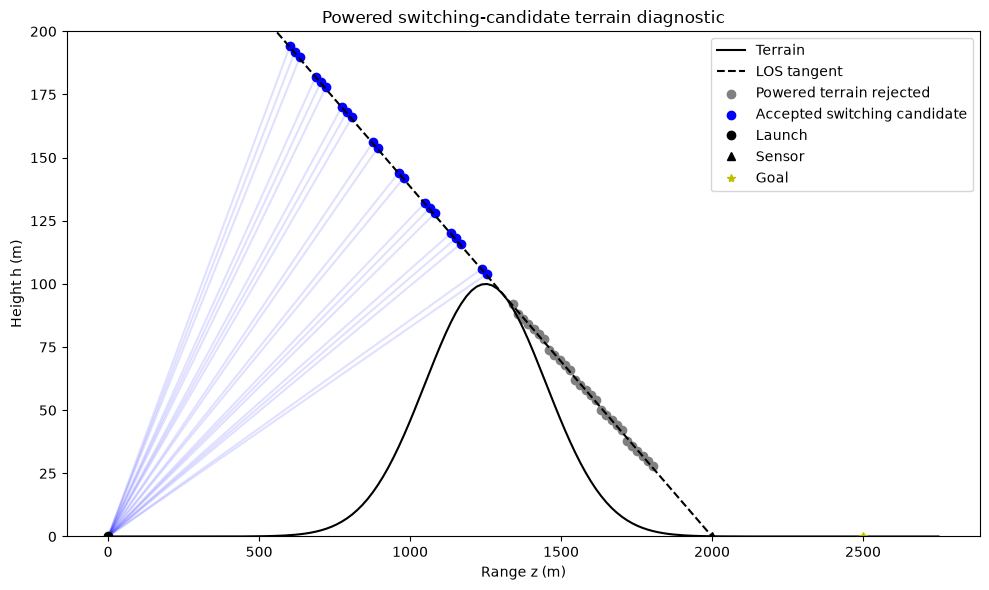

In [8]:
def powered_record(iz, ih):
    """Evaluate powered acoustic and time cost from launch to one switch cell."""
    mission, vehicle, solver, weights = config['mission'], config['vehicle'], config['solver'], config['weights']
    z_start, h_start = mission['z_start'], mission['h_start']; z_switch, h_switch = z_grid[iz], h_grid[ih]
    delta_z, delta_h = z_switch-z_start, h_switch-h_start; powered_distance = np.hypot(delta_z, delta_h)
    if powered_distance <= 0.0: return None
    powered_time = powered_distance / vehicle['powered_speed']; sample_count = max(solver['segment_check_count'], 25)
    fractions = np.linspace(0.0, 1.0, sample_count); z_samples = z_start + fractions*delta_z; h_samples = h_start + fractions*delta_h
    relative_altitude = altitude_above_terrain(z_samples, h_samples); tolerance = solver['terrain_numerical_tolerance']
    if np.any(relative_altitude[1:-1] < -tolerance) or relative_altitude[-1] < -tolerance: return None
    acoustic_rates = np.array([float(PoweredAcousticRateFunction(zv, hv, vehicle['powered_speed'])) for zv, hv in zip(z_samples, h_samples)], dtype=float)
    powered_acoustic_hazard = np.trapezoid(acoustic_rates, fractions*powered_time); powered_cost = weights['detection']*powered_acoustic_hazard + weights['time']*powered_time
    glide_cost_to_go = CostToGo[iz, ih]
    if not np.isfinite(glide_cost_to_go): return None
    return {'switch_iz':int(iz), 'switch_ih':int(ih), 'z_switch':float(z_switch), 'h_switch':float(h_switch), 'powered_distance':float(powered_distance), 'powered_time':float(powered_time), 'minimum_powered_terrain_margin':float(np.min(relative_altitude[1:])), 'powered_acoustic_hazard':float(powered_acoustic_hazard), 'powered_cost':float(powered_cost), 'glide_cost_to_go':float(glide_cost_to_go), 'total_mission_cost':float(powered_cost+glide_cost_to_go)}
candidate_diagnostics = {'all_z_cells':0, 'tangent_in_grid':0, 'within_tangent_tolerance':0, 'finite_projected_cost':0, 'finite_cost_to_go':0, 'powered_terrain_clear':0}
switch_records, powered_rejected_coordinates, candidate_coordinates = [], [], []
for iz, z_value in enumerate(z_grid):
    candidate_diagnostics['all_z_cells'] += 1; tangent_height = tangent_slope*z_value + tangent_intercept
    if tangent_height < h_grid[0] or tangent_height > h_grid[-1]: continue
    candidate_diagnostics['tangent_in_grid'] += 1; ih = int(np.argmin(np.abs(h_grid-tangent_height))); tangent_error = abs(h_grid[ih]-tangent_height)
    if tangent_error > config['solver']['tangent_tolerance']: continue
    candidate_diagnostics['within_tangent_tolerance'] += 1
    if not np.isfinite(ProjectedCost[iz, ih]): continue
    candidate_diagnostics['finite_projected_cost'] += 1
    if not np.isfinite(CostToGo[iz, ih]): continue
    candidate_diagnostics['finite_cost_to_go'] += 1; candidate_coordinates.append((z_grid[iz], h_grid[ih]))
    record = powered_record(iz, ih)
    if record is None: powered_rejected_coordinates.append((z_grid[iz], h_grid[ih])); continue
    candidate_diagnostics['powered_terrain_clear'] += 1; record['tangent_height'] = float(tangent_height); record['tangent_grid_error'] = float(tangent_error); switch_records.append(record)
print('Switching candidate diagnostics:')
for key, value in candidate_diagnostics.items(): print(f'  {key}: {value}')
assert candidate_diagnostics['finite_cost_to_go'] > 0, 'No LOS-tangent candidates have finite projected cost-to-go.'
if not switch_records: raise RuntimeError('No valid switching candidates remain after tangent, projected-cost, cost-to-go, and powered-terrain checks. Diagnostics: ' + str(candidate_diagnostics))
switch_records.sort(key=lambda record:record['total_mission_cost']); optimal_switch_record=switch_records[0]; print('Five best switching candidates:')
for record in switch_records[:5]: print(record)
assert np.isfinite(optimal_switch_record['total_mission_cost'])
figure, axis = plt.subplots(figsize=config['visualization']['figure_size'])
axis.plot(terrain_z, terrain_h, color='black', label='Terrain'); axis.plot(z_grid, tangent_slope*z_grid+tangent_intercept, 'k--', label='LOS tangent')
if powered_rejected_coordinates: axis.scatter(*np.asarray(powered_rejected_coordinates).T, color='gray', label='Powered terrain rejected')
if switch_records:
    accepted = np.array([(record['z_switch'], record['h_switch']) for record in switch_records]); axis.scatter(accepted[:,0], accepted[:,1], color='blue', label='Accepted switching candidate')
    for record in switch_records: axis.plot([config['mission']['z_start'], record['z_switch']], [config['mission']['h_start'], record['h_switch']], color='blue', alpha=0.12)
axis.plot(config['mission']['z_start'], config['mission']['h_start'], 'ko', label='Launch'); axis.plot(config['mission']['z_sensor'], config['mission']['h_sensor'], 'k^', label='Sensor'); axis.plot(config['mission']['z_goal'], config['mission']['h_goal'], 'y*', label='Goal')
axis.set(xlabel='Range z (m)', ylabel='Height h (m)', ylim=(config['grid']['h_min'], config['grid']['h_max'])); axis.legend(); axis.set_title('Powered switching-candidate terrain diagnostic'); figure.tight_layout(); plt.show()
iz,ih=optimal_switch_record['switch_iz'],optimal_switch_record['switch_ih']; path_indices=[]; visited=set()
for _ in range(config['solver']['max_path_steps']):
    path_indices.append((iz,ih))
    if goal_mask[iz,ih]: break
    if (iz,ih) in visited or NextIndexZ[iz,ih]<0: raise RuntimeError('Invalid or looping projected policy.')
    visited.add((iz,ih)); niz,nih=NextIndexZ[iz,ih],NextIndexH[iz,ih]; assert CostToGo[niz,nih] < CostToGo[iz,ih]+config['solver']['convergence_tolerance']; iz,ih=niz,nih
else: raise RuntimeError('Maximum path steps exceeded.')
optimal_glide_path=np.array([(z_grid[i],h_grid[j]) for i,j in path_indices]); assert np.all(np.diff(optimal_glide_path[:,0])>0); assert np.all(np.diff(optimal_glide_path[:,1])<=config['solver']['convergence_tolerance'])
powered_path=np.array([(config['mission']['z_start'],config['mission']['h_start']),(optimal_switch_record['z_switch'],optimal_switch_record['h_switch'])])


## 9. Validation and Final Visualization

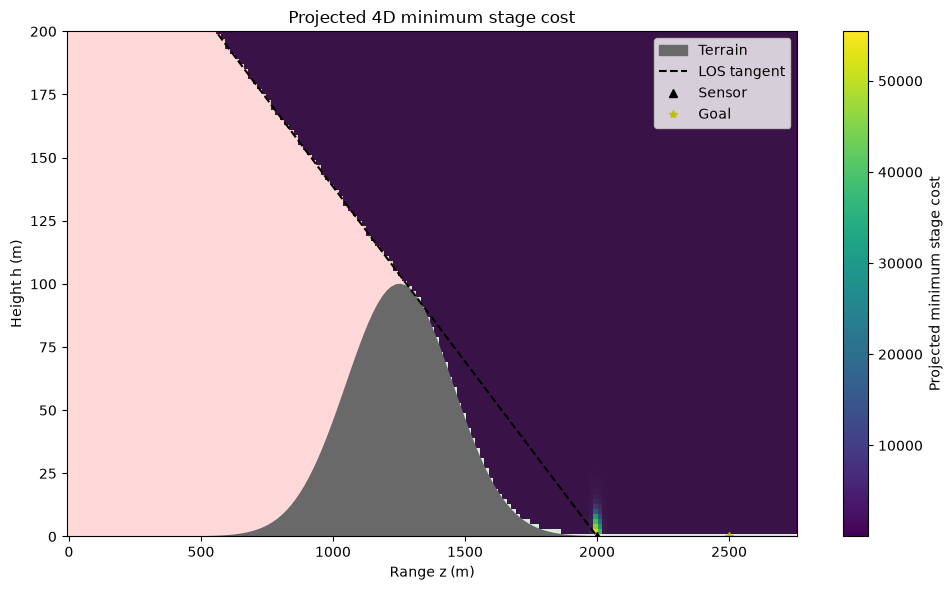

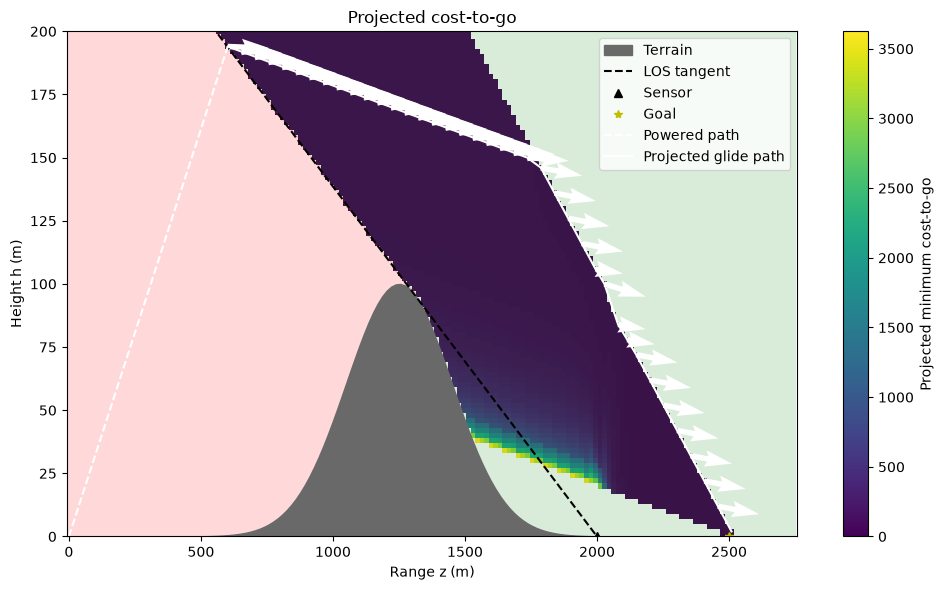

In [9]:
def overlay(axis):
    axis.contourf(grid_z,grid_h,occlusion_mask.astype(int),levels=[-.5,.5,1.5],colors=['green','red'],alpha=.15); axis.fill_between(terrain_z,terrain_h,color='dimgray',label='Terrain'); axis.plot(z_grid,tangent_slope*z_grid+tangent_intercept,'k--',label='LOS tangent'); axis.plot(p['z_sensor'],p['h_sensor'],'k^',label='Sensor'); axis.plot(p['z_goal'],p['h_goal'],'y*',label='Goal'); axis.set(xlabel='Range z (m)',ylabel='Height h (m)',ylim=(config['grid']['h_min'],config['grid']['h_max']))
for values,title,label,path in [(ProjectedCost,'Projected 4D minimum stage cost','Projected minimum stage cost',False),(CostToGo,'Projected cost-to-go','Projected minimum cost-to-go',True)]:
    fig,ax=plt.subplots(figsize=config['visualization']['figure_size']); image=ax.pcolormesh(z_grid,h_grid,np.ma.masked_invalid(values).T,shading='auto',cmap=config['visualization']['cost_colormap']); overlay(ax)
    if path: ax.plot(powered_path[:,0],powered_path[:,1],'w--',label='Powered path'); ax.plot(optimal_glide_path[:,0],optimal_glide_path[:,1],'w-',label='Projected glide path'); dpath=np.diff(optimal_glide_path,axis=0); ax.quiver(optimal_glide_path[:-1,0],optimal_glide_path[:-1,1],dpath[:,0],dpath[:,1],color='white')
    ax.set_title(title); ax.legend(); fig.colorbar(image,ax=ax,label=label); fig.tight_layout()
plt.show()


## 10. Reduced-Order Approximation Summary

This notebook uses a reduced-order planning approximation: 4D local stage-cost evaluation → minimum-cost projection over speed and glide angle → 2D projected cost-to-go propagation → projected-policy path extraction. Because speed and glide angle are minimized locally before Bellman propagation, this is not mathematically equivalent to full 4D dynamic programming. It is retained as the intended reduced-order approximation.

## 11. Final Projected Cost-to-Go Mission Plot

The heatmap is the numerical projected 2D cost-to-go map produced from the symbolic 4D local stage-cost model.

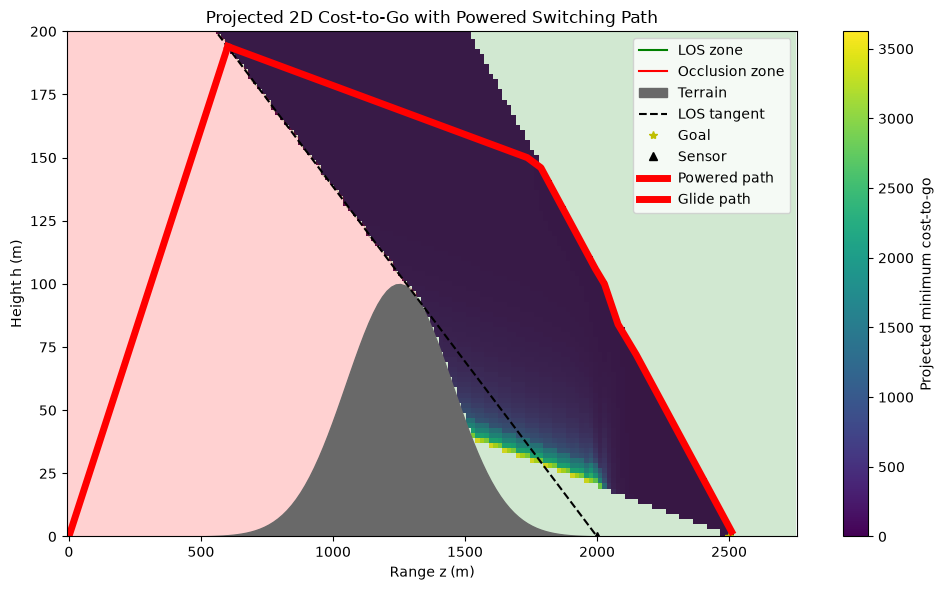

In [10]:
assert np.any(np.isfinite(CostToGo))
figure, axis = plt.subplots(figsize=config['visualization']['figure_size'])
cost_image = axis.pcolormesh(z_grid, h_grid, np.ma.masked_invalid(CostToGo).T, shading='auto', cmap=config['visualization']['cost_colormap'])
axis.contourf(grid_z, grid_h, occlusion_mask.astype(int), levels=[-0.5, 0.5, 1.5], colors=['green', 'red'], alpha=0.18)
axis.plot([], [], color='green', label='LOS zone'); axis.plot([], [], color='red', label='Occlusion zone')
axis.fill_between(terrain_z, terrain_h, color='dimgray', label='Terrain')
axis.plot(z_grid, tangent_slope*z_grid+tangent_intercept, 'k--', label='LOS tangent')
axis.plot(config['mission']['z_goal'], config['mission']['h_goal'], 'y*', label='Goal')
axis.plot(config['mission']['z_sensor'], config['mission']['h_sensor'], 'k^', label='Sensor')
axis.plot(powered_path[:, 0], powered_path[:, 1], color='red', linestyle='-', linewidth=5, label='Powered path')
axis.plot(optimal_glide_path[:, 0], optimal_glide_path[:, 1], color='red', linestyle='-', linewidth=5, label='Glide path')
axis.set(xlabel='Range z (m)', ylabel='Height h (m)', ylim=(config['grid']['h_min'], config['grid']['h_max']), title='Projected 2D Cost-to-Go with Powered Switching Path')
axis.legend(loc='upper right'); figure.colorbar(cost_image, ax=axis, label='Projected minimum cost-to-go'); figure.tight_layout(); plt.show()


## 12. Sensor-Location Full-Replanning Extension

This initial coarse sweep evaluates terrain-following sensor locations independently. It validates complete replanning before any smoothness or gradient-based outer optimization is attempted.

In [11]:
from copy import deepcopy
import time
import warnings

sensor_sweep_config = {
    'z_min': 1500.0, 'z_max': 2400.0, 'count': 10, 'mount_height': 0.0,
    'pod_weight': 0.8, 'los_area_weight': 0.2, 'cache_precision': 8,
    'continue_on_failure': True, 'store_full_maps': False, 'store_full_result_for_best': True,
    'hazard_reference': 1.0, 'radar_rate_scale': 1.0,
    'radial_velocity_rate_scale': 1.0, 'acoustic_rate_scale': 1.0,
    'use_diagnostic_hazard_normalization': True,
    'minimum_required_success_ratio': 0.7, 'debug_sensor_positions': [],
}
assert sensor_sweep_config['pod_weight'] >= 0 and sensor_sweep_config['los_area_weight'] >= 0
assert np.isclose(sensor_sweep_config['pod_weight'] + sensor_sweep_config['los_area_weight'], 1.0)
config['solver']['switch_tangent_band_cells'] = 2
config['solver']['switch_boundary_penalty_weight'] = 0.0
config['solver']['los_boundary_tolerance'] = 1.5 * (h_grid[1] - h_grid[0])
sensor_response_cache = {}

def summarize_finite(values):
    """Return robust summary statistics for finite diagnostic values."""
    values=np.asarray(values,dtype=float); values=values[np.isfinite(values)]
    if values.size==0: return {'min':np.nan,'median':np.nan,'p95':np.nan,'max':np.nan}
    return {'min':float(np.min(values)),'median':float(np.median(values)),'p95':float(np.percentile(values,95)),'max':float(np.max(values))}

def sensor_position_from_z(z_sensor_value, terrain_function, mount_height):
    """Return terrain-following sensor coordinates from longitudinal position."""
    z_sensor_value = float(z_sensor_value)
    return z_sensor_value, float(terrain_function(z_sensor_value) + mount_height)

def compute_sensor_dependent_los(z_sensor_value, h_sensor_value, terrain_function, z_values, h_values, local_config):
    """Compute the goal-side terrain tangent and candidate-specific visibility masks."""
    derivative = terrain_interpolant.derivative(); samples = z_values[z_values < z_sensor_value]
    if samples.size < 2: return {'success': False, 'failure_reason': 'no_valid_los_tangent'}
    residual = (terrain_function(samples)-h_sensor_value)/(samples-z_sensor_value)-derivative(samples)
    roots = np.flatnonzero(np.signbit(residual[:-1]) != np.signbit(residual[1:]))
    if roots.size == 0: return {'success': False, 'failure_reason': 'no_valid_los_tangent'}
    root_diagnostics=[]; root_candidates=[]
    for root in roots:
        left,right=samples[root],samples[root+1]
        for _ in range(64):
            middle=.5*(left+right); f_left=(terrain_function(left)-h_sensor_value)/(left-z_sensor_value)-derivative(left); f_mid=(terrain_function(middle)-h_sensor_value)/(middle-z_sensor_value)-derivative(middle)
            if np.signbit(f_left)==np.signbit(f_mid): left=middle
            else: right=middle
        tangent_z=.5*(left+right); tangent_h=float(terrain_function(tangent_z)); slope=(tangent_h-h_sensor_value)/(tangent_z-z_sensor_value); intercept=h_sensor_value-slope*tangent_z
        goal_margin=local_config['mission']['h_goal']-(slope*local_config['mission']['z_goal']+intercept)
        if tangent_z>=z_sensor_value: root_diagnostics.append('tangent_not_left_of_sensor'); continue
        if goal_margin < -local_config['solver']['los_boundary_tolerance']: root_diagnostics.append('goal_on_occluded_side'); continue
        zz,hh=np.meshgrid(z_values,h_values,indexing='ij'); visible=(~((zz<tangent_z)&(hh<slope*zz+intercept)))
        score=np.count_nonzero(visible & (hh>=np.array([terrain_function(z) for z in z_values])[:,None]+local_config['solver']['terrain_clearance']))
        root_candidates.append((score,tangent_z,tangent_h,slope,intercept))
    if not root_candidates: return {'success':False,'failure_reason':'no_geometrically_valid_los_tangent','root_diagnostics':root_diagnostics}
    _,tangent_z,tangent_h,slope,intercept=max(root_candidates,key=lambda item:item[0])
    left, right = tangent_z, tangent_z
    if not (z_values[0] <= tangent_z <= z_values[-1]): return {'success': False, 'failure_reason': 'no_valid_los_tangent'}
    slope=(tangent_h-h_sensor_value)/(tangent_z-z_sensor_value); intercept=h_sensor_value-slope*z_sensor_value
    zz,hh=np.meshgrid(z_values,h_values,indexing='ij'); occlusion=(zz<tangent_z)&(hh<slope*zz+intercept)
    return {'success': True,'failure_reason':None,'tangent_z':float(tangent_z),'tangent_h':tangent_h,'tangent_slope':float(slope),'tangent_intercept':float(intercept),'los_mask':~occlusion,'occlusion_mask':occlusion}

def create_variable_sensor_functions(local_config):
    """Create CasADi instantaneous-rate functions with explicit sensor coordinates."""
    zz,hh,vv,gg,zs,hs=ca.SX.sym('z'),ca.SX.sym('h'),ca.SX.sym('v'),ca.SX.sym('gamma'),ca.SX.sym('z_sensor'),ca.SX.sym('h_sensor')
    d=local_config['detection']; rng=ca.fmax(ca.sqrt((zs-zz)**2+(hs-hh)**2),d['range_floor'])
    los_angle=ca.atan2(hs-hh,zs-zz); aspect=ca.atan2(ca.sin(gg-los_angle),ca.cos(gg-los_angle))
    rcs=d['rcs_min']+(d['rcs_max']-d['rcs_min'])*ca.cos(aspect)**2
    radar=d['radar_coefficient']*rcs/rng**4
    radial=vv*(ca.cos(gg)*(zs-zz)+ca.sin(gg)*(hs-hh))/rng
    doppler=d['doppler_coefficient']*radial**2/rng**4
    acoustic=d['acoustic_coefficient']*vv**d['acoustic_speed_exponent']/rng**2
    return ca.Function('VariableSensorRates',[zz,hh,vv,gg,zs,hs],[radar,doppler,acoustic])

def solve_attacker_response_for_sensor(z_sensor_value, base_config, sweep_config, terrain_function, sensor_independent_data, return_full_maps=False):
    """Recompute the complete reduced-order attacker response for one sensor location."""
    key=round(float(z_sensor_value),sweep_config['cache_precision'])
    if not return_full_maps and key in sensor_response_cache: return sensor_response_cache[key]
    local_config=deepcopy(base_config); z_sensor,h_sensor=sensor_position_from_z(z_sensor_value,terrain_function,sweep_config['mount_height'])
    if not (local_config['grid']['z_min']<=z_sensor<=local_config['grid']['z_max']): return {'success':False,'failure_reason':'sensor_outside_domain','z_sensor':z_sensor,'h_sensor':h_sensor}
    local_config['mission']['z_sensor']=z_sensor; local_config['mission']['h_sensor']=h_sensor
    zg,hg,vg,gg=sensor_independent_data['z_grid'],sensor_independent_data['h_grid'],sensor_independent_data['v_grid'],sensor_independent_data['gamma_grid']
    los=compute_sensor_dependent_los(z_sensor,h_sensor,terrain_function,zg,hg,local_config)
    if not los['success']: return {'success':False,'failure_reason':los['failure_reason'],'z_sensor':z_sensor,'h_sensor':h_sensor}
    rates_function=create_variable_sensor_functions(local_config); shape=(zg.size,hg.size); terrain_valid_airspace_mask=np.zeros(shape,dtype=bool); J=np.full((zg.size,hg.size,vg.size,gg.size),np.inf)
    for iz,zv in enumerate(zg):
        for ih,hv in enumerate(hg):
            terrain_valid_airspace_mask[iz,ih]=hv>=terrain_function(zv)+local_config['solver']['terrain_clearance']
            if not (terrain_valid_airspace_mask[iz,ih] and los['los_mask'][iz,ih]): continue
            for iv,speed in enumerate(vg):
                for ig,angle in enumerate(gg):
                    if is_steady_glide_control_feasible(speed,angle,local_config):
                        radar,doppler,_=rates_function(zv,hv,speed,angle,z_sensor,h_sensor); scaled_rate=float(radar)*sweep_config['radar_rate_scale']+float(doppler)*sweep_config['radial_velocity_rate_scale']; J[iz,ih,iv,ig]=scaled_rate*local_config['solver']['dt_reference']*local_config['weights']['detection']+local_config['weights']['time']*local_config['solver']['dt_reference']
    los_visible_airspace_mask=terrain_valid_airspace_mask & los['los_mask']; glide_planning_valid_mask=los_visible_airspace_mask
    projected=np.full(shape,np.inf); pspeed=np.full(shape,np.nan); pgamma=np.full(shape,np.nan); psindex=np.full(shape,-1,dtype=int); pgindex=np.full(shape,-1,dtype=int)
    for iz in range(zg.size):
        for ih in range(hg.size):
            if np.any(np.isfinite(J[iz,ih])):
                flat=np.argmin(np.where(np.isfinite(J[iz,ih]),J[iz,ih],np.inf)); iv,ig=np.unravel_index(flat,J[iz,ih].shape); projected[iz,ih]=J[iz,ih,iv,ig]; pspeed[iz,ih]=vg[iv]; pgamma[iz,ih]=gg[ig]; psindex[iz,ih]=iv; pgindex[iz,ih]=ig
    if not np.any(np.isfinite(projected)): return {'success':False,'failure_reason':'no_finite_projected_cost','z_sensor':z_sensor,'h_sensor':h_sensor}
    goal=np.zeros(shape,dtype=bool)
    for iz,zv in enumerate(zg):
        for ih,hv in enumerate(hg): goal[iz,ih]=is_goal_region(zv,hv,local_config)
    value=np.full(shape,np.inf); nz=np.full(shape,-1,dtype=int); nh=np.full(shape,-1,dtype=int); value[goal]=0.0
    def edge_ok(iz,ih,jz,jh):
        dz,dh=zg[jz]-zg[iz],hg[jh]-hg[ih]
        if dz<0 or (dz==0 and dh==0) or dh>0 or not np.isfinite(pspeed[iz,ih]): return False
        edge_angle=np.arctan2(dh,dz); q=local_config['vehicle']; s=local_config['solver']
        if not (np.deg2rad(q['gamma_min_deg'])<=edge_angle<=np.deg2rad(q['gamma_max_deg']) and abs(edge_angle-pgamma[iz,ih])<=s['edge_gamma_tolerance']): return False
        fractions=np.linspace(0,1,s['segment_check_count']); samples=fractions[:-1] if goal[jz,jh] else fractions
        return all(hg[ih]+f*dh>=terrain_function(zg[iz]+f*dz)+s['terrain_clearance'] and not ((zg[iz]+f*dz<los['tangent_z']) and (hg[ih]+f*dh<los['tangent_slope']*(zg[iz]+f*dz)+los['tangent_intercept'])) for f in samples)
    for _ in range(zg.size):
        before=np.isfinite(value); old=value.copy()
        for iz in range(zg.size-1,-1,-1):
            for ih in range(hg.size):
                if goal[iz,ih] or not np.isfinite(projected[iz,ih]): continue
                choices=[]
                for di in range(0,local_config['solver']['max_forward_cells']+1):
                    for dj in range(-local_config['solver']['max_descent_cells'],1):
                        jz,jh=iz+di,ih+dj
                        if jz<zg.size and jh>=0 and np.isfinite(value[jz,jh]) and edge_ok(iz,ih,jz,jh):
                            edge_time=np.hypot(zg[jz]-zg[iz],hg[jh]-hg[ih])/pspeed[iz,ih]; choices.append((projected[iz,ih]*edge_time/local_config['solver']['dt_reference']+value[jz,jh],jz,jh))
                if choices: value[iz,ih],nz[iz,ih],nh[iz,ih]=min(choices,key=lambda item:item[0])
        common=before&np.isfinite(value); change=np.max(np.abs(value[common]-old[common])) if np.any(common) else 0.0
        if not np.any(np.isfinite(value)&~before) and change<local_config['solver']['convergence_tolerance']: break
    if not np.any(np.isfinite(value)): return {'success':False,'failure_reason':'no_finite_cost_to_go','z_sensor':z_sensor,'h_sensor':h_sensor}
    switch_diagnostics={'z_grid_cells_checked':0,'tangent_inside_vertical_grid':0,'within_tangent_tolerance':0,'terrain_valid_switch_cell':0,'los_valid_switch_cell':0,'finite_projected_cost':0,'finite_cost_to_go':0,'powered_segment_terrain_clear':0,'accepted_switch_candidates':0}
    records=[]; dh=float(hg[1]-hg[0]); band=local_config['solver']['switch_tangent_band_cells']*dh
    for iz,zv in enumerate(zg):
        switch_diagnostics['z_grid_cells_checked']+=1; target=los['tangent_slope']*zv+los['tangent_intercept']
        if target<hg[0]-band or target>hg[-1]+band: continue
        switch_diagnostics['tangent_inside_vertical_grid']+=1
        candidate_indices=np.flatnonzero(np.abs(hg-target)<=band)
        for ih in candidate_indices:
            switch_diagnostics['within_tangent_tolerance']+=1
            if not terrain_valid_airspace_mask[iz,ih]: continue
            switch_diagnostics['terrain_valid_switch_cell']+=1
            if hg[ih]-target < -local_config['solver']['los_boundary_tolerance']: continue
            switch_diagnostics['los_valid_switch_cell']+=1
            if not np.isfinite(projected[iz,ih]): continue
            switch_diagnostics['finite_projected_cost']+=1
            if not np.isfinite(value[iz,ih]): continue
            switch_diagnostics['finite_cost_to_go']+=1
            distance=np.hypot(zv-local_config['mission']['z_start'],hg[ih]-local_config['mission']['h_start']); f=np.linspace(0,1,max(25,local_config['solver']['segment_check_count'])); zsamp=f*zv; hsamp=f*hg[ih]
            terrain_margin=altitude_above_terrain(zsamp,hsamp); minimum_powered_terrain_margin=float(np.min(terrain_margin))
            if np.any(terrain_margin[1:-1] < -local_config['solver']['terrain_numerical_tolerance']) or terrain_margin[-1] < -local_config['solver']['terrain_numerical_tolerance']: continue
            switch_diagnostics['powered_segment_terrain_clear']+=1
            acoustic=np.array([float(rates_function(x,y,local_config['vehicle']['powered_speed'],0.0,z_sensor,h_sensor)[2])*sweep_config['acoustic_rate_scale'] for x,y in zip(zsamp,hsamp)]); powered_time=distance/local_config['vehicle']['powered_speed']; phazard=np.trapezoid(acoustic,f*powered_time); pcost=local_config['weights']['detection']*phazard+local_config['weights']['time']*powered_time; tangent_error=abs(hg[ih]-target); boundary_penalty=sweep_config.get('switch_boundary_penalty_weight',0.0)*tangent_error/max(dh,1e-12)
            switch_diagnostics['accepted_switch_candidates']+=1; records.append({'iz':iz,'ih':ih,'z':zv,'h':hg[ih],'tangent_error':tangent_error,'minimum_powered_terrain_margin':minimum_powered_terrain_margin,'powered_time':powered_time,'powered_hazard':phazard,'cost':pcost+boundary_penalty+value[iz,ih]})
    if not records:
        failure_map=[('tangent_inside_vertical_grid','no_tangent_cells_inside_grid'),('within_tangent_tolerance','no_cells_within_tangent_tolerance'),('terrain_valid_switch_cell','all_tangent_cells_below_terrain'),('los_valid_switch_cell','all_tangent_cells_outside_los'),('finite_projected_cost','no_finite_projected_cost_on_tangent'),('finite_cost_to_go','no_finite_cost_to_go_on_tangent'),('powered_segment_terrain_clear','all_powered_segments_intersect_terrain')]
        reason=next((label for key,label in failure_map if switch_diagnostics[key]==0),'no_valid_switching_candidate'); return {'success':False,'failure_reason':reason,'z_sensor':z_sensor,'h_sensor':h_sensor,'switch_diagnostics':switch_diagnostics,'finite_projected_count':int(np.count_nonzero(np.isfinite(projected))),'finite_cost_to_go_count':int(np.count_nonzero(np.isfinite(value))),'finite_projected_on_tangent':switch_diagnostics['finite_projected_cost'],'finite_cost_to_go_on_tangent':switch_diagnostics['finite_cost_to_go']}
    best=min(records,key=lambda item:item['cost']); iz,ih=best['iz'],best['ih']; indices=[]; visited=set()
    for _ in range(local_config['solver']['max_path_steps']):
        indices.append((iz,ih))
        if goal[iz,ih]: break
        if (iz,ih) in visited or nz[iz,ih]<0: return {'success':False,'failure_reason':'path_extraction_failed','z_sensor':z_sensor,'h_sensor':h_sensor}
        visited.add((iz,ih)); iz,ih=nz[iz,ih],nh[iz,ih]
    glide_path=np.array([(zg[i],hg[j]) for i,j in indices]); powered_path=np.array([(local_config['mission']['z_start'],local_config['mission']['h_start']),(best['z'],best['h'])])
    glide_radar=0.0; glide_doppler=0.0; glide_time=0.0
    for (iz,ih),(jz,jh) in zip(indices[:-1],indices[1:]):
        edge_time=np.hypot(zg[jz]-zg[iz],hg[jh]-hg[ih])/pspeed[iz,ih]; radar,doppler,_=rates_function(zg[iz],hg[ih],pspeed[iz,ih],pgamma[iz,ih],z_sensor,h_sensor); glide_radar+=float(radar)*sweep_config['radar_rate_scale']*edge_time; glide_doppler+=float(doppler)*sweep_config['radial_velocity_rate_scale']*edge_time; glide_time+=edge_time
    hazard=best['powered_hazard']+glide_radar+glide_doppler; pod=1-np.exp(-hazard); dz=float(np.diff(zg)[0]); cell_area=dz*dh; admissible_area=np.count_nonzero(terrain_valid_airspace_mask)*cell_area; los_area=np.count_nonzero(los_visible_airspace_mask)*cell_area
    if admissible_area<=0.0: raise RuntimeError('Admissible airspace area is zero.')
    normalized=float(np.clip(los_area/admissible_area,0.0,1.0)); assert -1e-12<=los_area/admissible_area<=1.0+1e-12
    normalized_detection_score=hazard/(hazard+sweep_config['hazard_reference']) if sweep_config['use_diagnostic_hazard_normalization'] else pod
    result={'success':True,'failure_reason':None,'z_sensor':z_sensor,'h_sensor':h_sensor,'tangent_z':los['tangent_z'],'tangent_h':los['tangent_h'],'tangent_slope':los['tangent_slope'],'tangent_intercept':los['tangent_intercept'],'admissible_airspace_area':float(admissible_area),'los_area':float(los_area),'normalized_los_area':normalized,'powered_acoustic_hazard':float(best['powered_hazard']),'glide_radar_hazard':float(glide_radar),'glide_radial_velocity_hazard':float(glide_doppler),'glide_detection_hazard':float(glide_radar+glide_doppler),'mission_detection_hazard':float(hazard),'mission_pod':float(pod),'normalized_detection_score':float(normalized_detection_score),'attacker_powered_cost':float(best['cost']-value[best['iz'],best['ih']]),'attacker_glide_cost':float(value[best['iz'],best['ih']]),'attacker_total_cost':float(best['cost']),'switch_z':float(best['z']),'switch_h':float(best['h']),'powered_time':float(best['powered_time']),'glide_time':float(glide_time),'total_time':float(best['powered_time']+glide_time),'powered_path_length':float(np.hypot(best['z'],best['h'])),'glide_path_length':float(np.sum(np.hypot(np.diff(glide_path[:,0]),np.diff(glide_path[:,1])))),'total_path_length':float(np.hypot(best['z'],best['h'])+np.sum(np.hypot(np.diff(glide_path[:,0]),np.diff(glide_path[:,1])))),'powered_path':powered_path,'glide_path':glide_path,'switch_diagnostics':switch_diagnostics,'finite_projected_count':int(np.count_nonzero(np.isfinite(projected))),'finite_cost_to_go_count':int(np.count_nonzero(np.isfinite(value))),'finite_projected_on_tangent':switch_diagnostics['finite_projected_cost'],'finite_cost_to_go_on_tangent':switch_diagnostics['finite_cost_to_go'],'tangent_band_candidate_count':switch_diagnostics['within_tangent_tolerance'],'powered_clear_candidate_count':switch_diagnostics['powered_segment_terrain_clear']}
    result['defender_utility']=float(sweep_config['pod_weight']*normalized_detection_score+sweep_config['los_area_weight']*normalized)
    if hazard>20.0: warnings.warn('Mission detection hazard is strongly saturated. Calibrate detection-rate coefficients or use the provisional normalized detection score for sweep comparison.')
    print('Admissible airspace cells:',np.count_nonzero(terrain_valid_airspace_mask)); print('LOS-visible airspace cells:',np.count_nonzero(los_visible_airspace_mask)); print('Normalized LOS area:',normalized)
    result['detection_diagnostics']={'radar_rate':summarize_finite([glide_radar/max(glide_time,1e-12)]),'radial_velocity_rate':summarize_finite([glide_doppler/max(glide_time,1e-12)]),'acoustic_rate':summarize_finite([best['powered_hazard']/max(best['powered_time'],1e-12)]),'radar_hazard_increment':summarize_finite([glide_radar]),'radial_velocity_hazard_increment':summarize_finite([glide_doppler]),'acoustic_hazard_increment':summarize_finite([best['powered_hazard']])}
    if return_full_maps: result.update({'J4D':J,'ProjectedCost':projected,'ProjectedOptimalSpeed':pspeed,'ProjectedOptimalGamma':pgamma,'CostToGo':value,'NextIndexZ':nz,'NextIndexH':nh,'los_mask':los['los_mask'],'occlusion_mask':los['occlusion_mask'],'terrain_valid_airspace_mask':terrain_valid_airspace_mask,'los_visible_airspace_mask':los_visible_airspace_mask,'glide_planning_valid_mask':glide_planning_valid_mask})
    if not return_full_maps: sensor_response_cache[key]=result
    return result

sensor_independent_data={'z_grid':z_grid,'h_grid':h_grid,'v_grid':v_grid,'gamma_grid':gamma_grid}
sensor_independent_data={'z_grid':z_grid,'h_grid':h_grid,'v_grid':v_grid,'gamma_grid':gamma_grid}
z_sensor_candidates=np.linspace(sensor_sweep_config['z_min'],sensor_sweep_config['z_max'],sensor_sweep_config['count']); assert np.all(z_sensor_candidates>=z_grid[0]) and np.all(z_sensor_candidates<=z_grid[-1]); sensor_sweep_results=[]; sweep_start=time.perf_counter()
print('Sensor candidates (z, terrain-following h):'); [print(float(z_value),sensor_position_from_z(z_value,terrain,sensor_sweep_config['mount_height'])[1]) for z_value in z_sensor_candidates]
original_fixed_sensor_baseline={'z_sensor':config['mission']['z_sensor'],'h_sensor':config['mission']['h_sensor']}
terrain_following_baseline=solve_attacker_response_for_sensor(2000.0,config,sensor_sweep_config,terrain,sensor_independent_data)
for number,z_candidate in enumerate(z_sensor_candidates,1):
    started=time.perf_counter(); result=solve_attacker_response_for_sensor(z_candidate,config,sensor_sweep_config,terrain,sensor_independent_data); sensor_sweep_results.append(result)
    print(f'[{number}/{len(z_sensor_candidates)}] z_sensor={result["z_sensor"]:.1f} h_sensor={result["h_sensor"]:.2f} success={result["success"]} utility={result.get("defender_utility",np.nan):.5g} runtime={time.perf_counter()-started:.1f}s');
    if not result['success']: print('Switch diagnostics:',result.get('switch_diagnostics',{}))
successful_sensor_results=[item for item in sensor_sweep_results if item['success']]; assert successful_sensor_results,'The sensor sweep produced no successful full-replanning evaluations.'
best_sensor_result=max(successful_sensor_results,key=lambda item:item['defender_utility']); best_sensor_full_result=solve_attacker_response_for_sensor(best_sensor_result['z_sensor'],config,sensor_sweep_config,terrain,sensor_independent_data,return_full_maps=True)
assert np.isclose(best_sensor_full_result['defender_utility'],best_sensor_result['defender_utility'],rtol=1e-8,atol=1e-10)
success_count=len(successful_sensor_results); failure_count=len(sensor_sweep_results)-success_count; success_ratio=success_count/len(sensor_sweep_results); print(f'Total sweep runtime: {time.perf_counter()-sweep_start:.1f}s'); print('Sweep success count:',success_count); print('Sweep failure count:',failure_count); print('Sweep success ratio:',success_ratio)
if success_ratio<sensor_sweep_config['minimum_required_success_ratio']: warnings.warn('Sensor sweep feasibility is below the required diagnostic threshold.')


Sensor candidates (z, terrain-following h):
1500.0 45.78335282459552
1600.0 21.626518177973455
1700.0 7.955951473818714
1800.0 2.279415112595047
1900.0 0.5086032457480654
2000.0 0.08838145394612283
2100.0 0.011961186186511525
2200.0 0.0012607105177048523
2300.0 0.00010348144836475312
2400.0 6.61482861576447e-06
Admissible airspace cells: 14643
LOS-visible airspace cells: 8337
Normalized LOS area: 0.5693505429215324
[1/10] z_sensor=1500.0 h_sensor=45.78 success=True utility=0.85519 runtime=27.7s
Admissible airspace cells: 14643
LOS-visible airspace cells: 8420
Normalized LOS area: 0.5750187803045824
[2/10] z_sensor=1600.0 h_sensor=21.63 success=True utility=0.83986 runtime=29.7s
Admissible airspace cells: 14643
LOS-visible airspace cells: 8551
Normalized LOS area: 0.5839650344874684
[3/10] z_sensor=1700.0 h_sensor=7.96 success=True utility=0.84033 runtime=32.1s
Admissible airspace cells: 14643
LOS-visible airspace cells: 8704
Normalized LOS area: 0.594413713036946
[4/10] z_sensor=1800.0

C:\Users\jeffe\AppData\Local\Temp\ipykernel_2176\3113982058.py:167: UserWarning: Mission detection hazard is strongly saturated. Calibrate detection-rate coefficients or use the provisional normalized detection score for sweep comparison.
  if hazard>20.0: warnings.warn('Mission detection hazard is strongly saturated. Calibrate detection-rate coefficients or use the provisional normalized detection score for sweep comparison.')


Admissible airspace cells: 14643
LOS-visible airspace cells: 9674
Normalized LOS area: 0.6606569692003005
[10/10] z_sensor=2400.0 h_sensor=0.00 success=True utility=0.93094 runtime=40.7s
Admissible airspace cells: 14643
LOS-visible airspace cells: 9674
Normalized LOS area: 0.6606569692003005
Total sweep runtime: 426.9s
Sweep success count: 5
Sweep failure count: 5
Sweep success ratio: 0.5


C:\Users\jeffe\AppData\Local\Temp\ipykernel_2176\3113982058.py:188: UserWarning: Sensor sweep feasibility is below the required diagnostic threshold.
  if success_ratio<sensor_sweep_config['minimum_required_success_ratio']: warnings.warn('Sensor sweep feasibility is below the required diagnostic threshold.')


### 12.6–12.9 Sweep Results, Visualizations, Validation, and Limitations

Failure summary: {'all_powered_segments_intersect_terrain': 5}
Top five sensor results:
2400.0 6.61482861576447e-06 0.9309404529631131
1800.0 2.279415112595047 0.8566410822985029
1500.0 45.78335282459552 0.8551891030160297
1700.0 7.955951473818714 0.8403280795308037
1600.0 21.626518177973455 0.8398560112982252


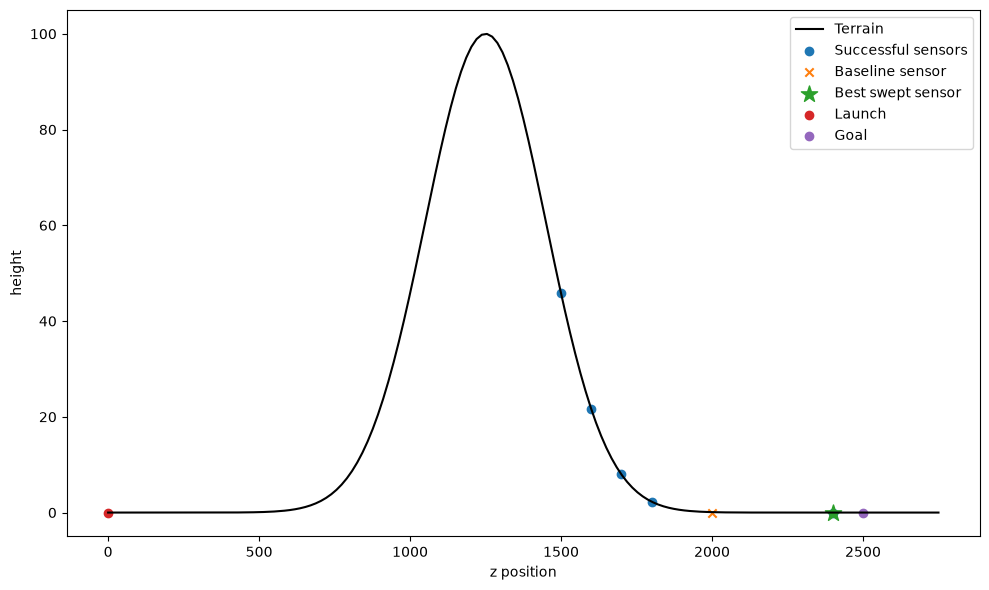

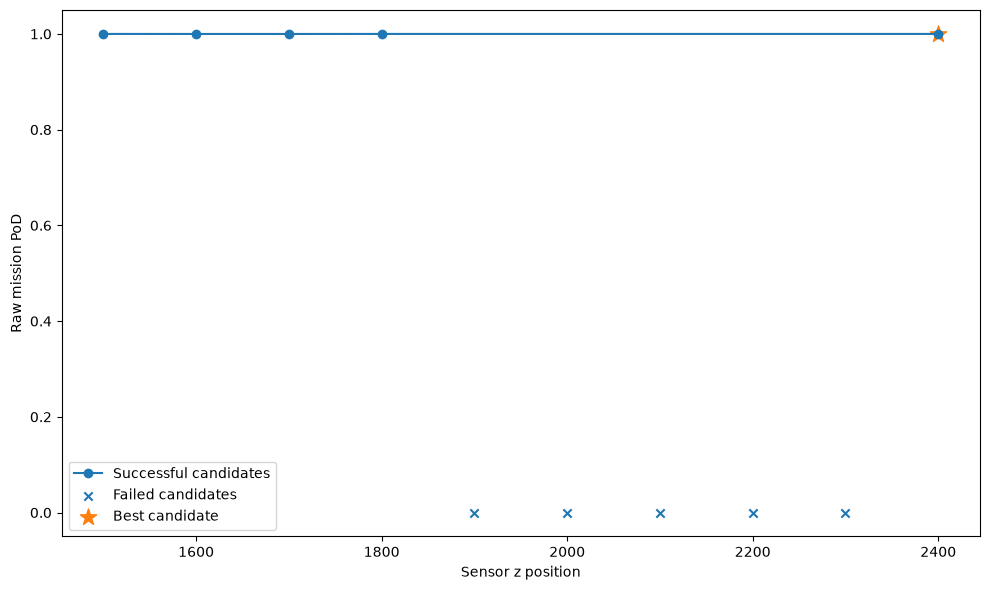

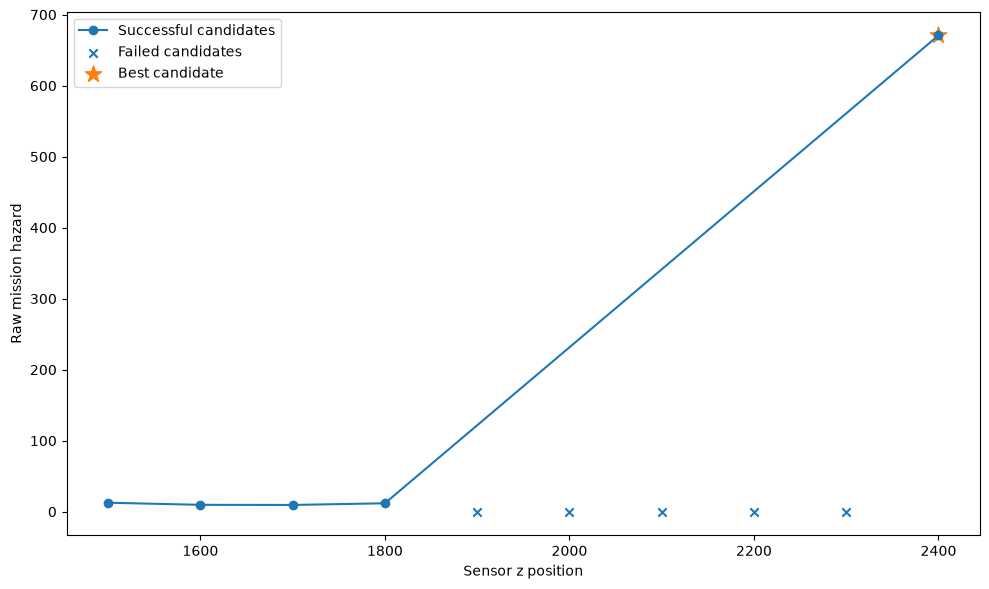

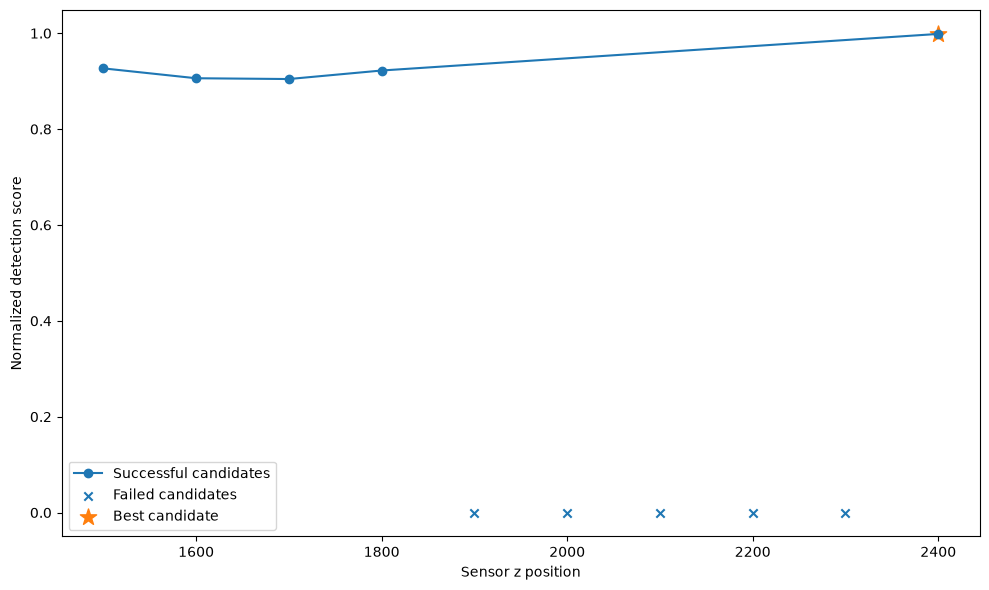

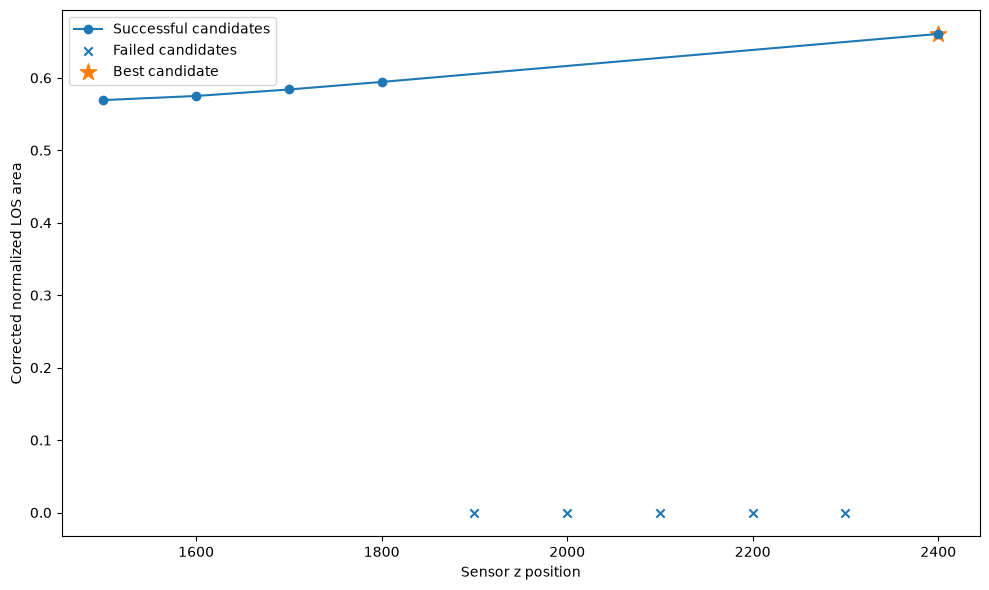

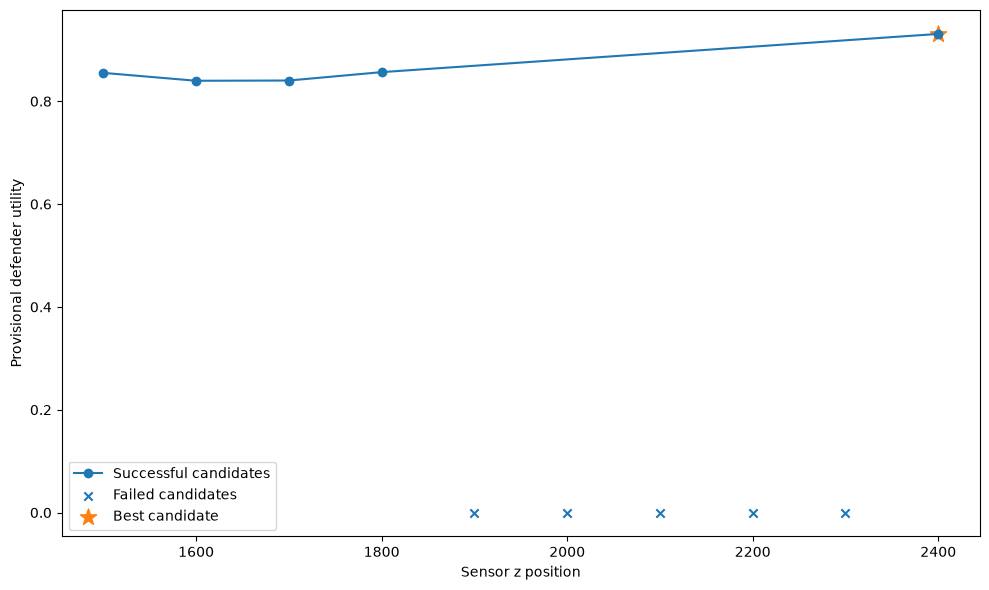

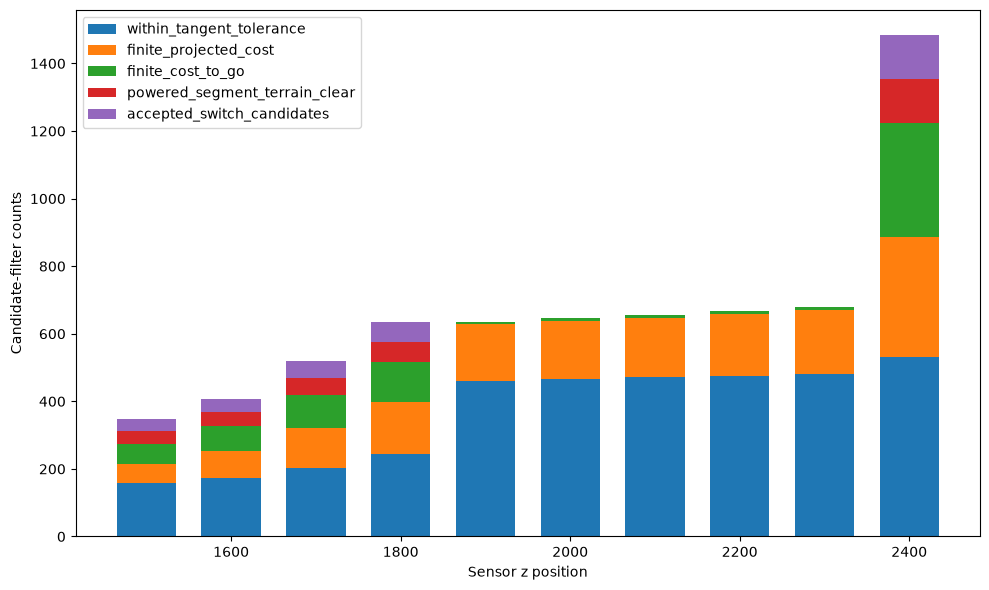

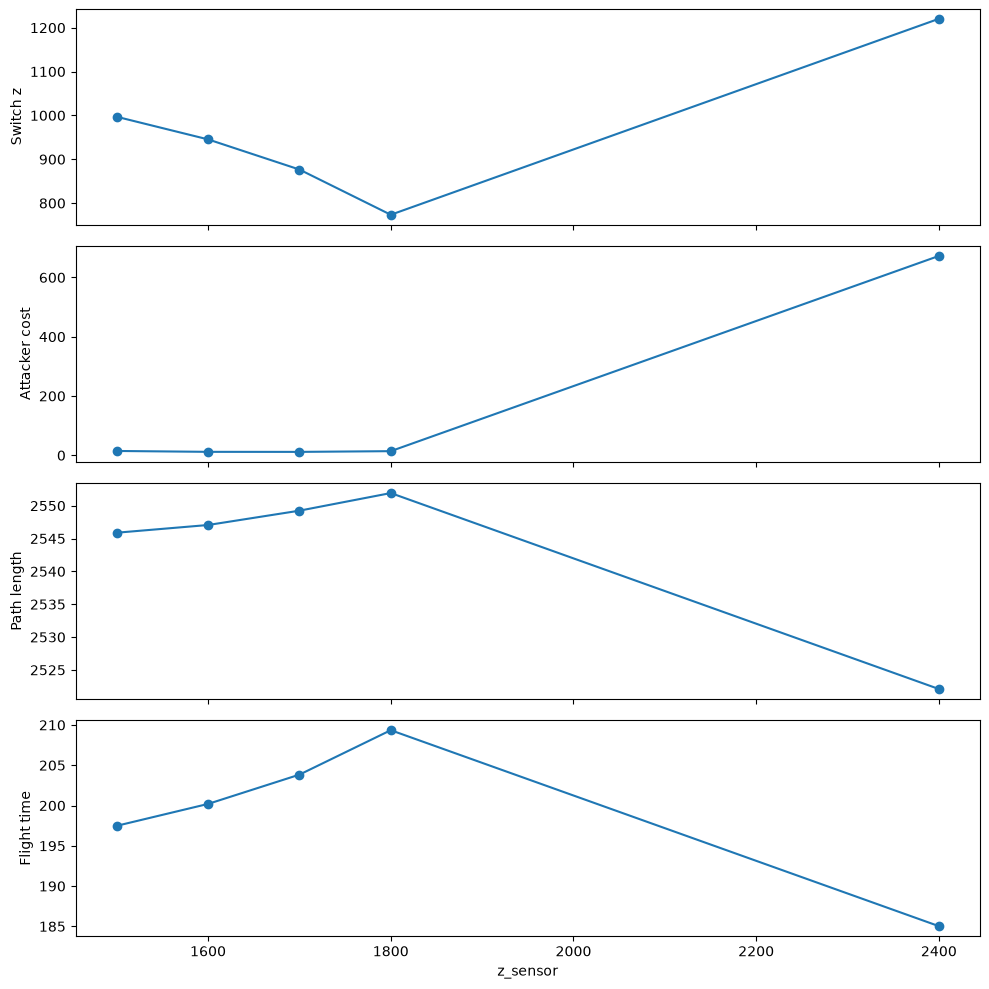

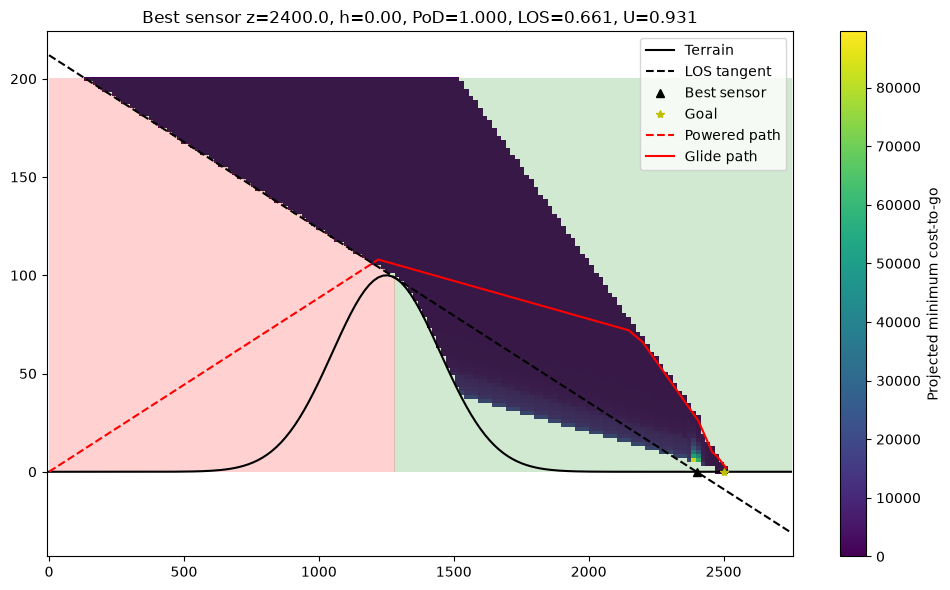

Baseline fixed sensor: {'z_sensor': 2000.0, 'h_sensor': 0.0}
Best swept sensor: {'success': True, 'failure_reason': None, 'z_sensor': 2400.0, 'h_sensor': 6.61482861576447e-06, 'tangent_z': 1285.9065336877366, 'tangent_h': 98.40130266943096, 'tangent_slope': -0.08832409401009983, 'tangent_intercept': 211.9778322390682, 'admissible_airspace_area': 503353.125, 'los_area': 332543.75, 'normalized_los_area': 0.6606569692003005, 'powered_acoustic_hazard': 0.009595647345435731, 'glide_radar_hazard': 578.9870414208398, 'glide_radial_velocity_hazard': 91.7411590604992, 'glide_detection_hazard': 670.728200481339, 'mission_detection_hazard': 670.7377961286844, 'mission_pod': 1.0, 'normalized_detection_score': 0.9985113239038161, 'attacker_powered_cost': 0.5929681625807461, 'attacker_glide_cost': 671.995113426689, 'attacker_total_cost': 672.5880815892698, 'switch_z': 1220.3125, 'switch_h': 108.0, 'powered_time': 58.33725152353592, 'glide_time': 126.69129453500922, 'total_time': 185.02854605854515, 

In [12]:
failure_counts={}
for result in sensor_sweep_results:
    if not result['success']: failure_counts[result['failure_reason']]=failure_counts.get(result['failure_reason'],0)+1
print('Failure summary:',failure_counts)
sensor_sweep_table=[{key:result.get(key,np.nan) for key in ('z_sensor','h_sensor','success','failure_reason','tangent_z','tangent_h','admissible_airspace_area','los_area','normalized_los_area','mission_detection_hazard','mission_pod','normalized_detection_score','powered_acoustic_hazard','glide_radar_hazard','glide_radial_velocity_hazard','attacker_total_cost','switch_z','switch_h','total_time','total_path_length','defender_utility','tangent_band_candidate_count','finite_projected_on_tangent','finite_cost_to_go_on_tangent','powered_clear_candidate_count')} for result in sensor_sweep_results]
print('Top five sensor results:')
for result in sorted(successful_sensor_results,key=lambda item:item['defender_utility'],reverse=True)[:5]: print(result['z_sensor'],result['h_sensor'],result['defender_utility'])
successful_z=np.array([result['z_sensor'] for result in successful_sensor_results]); successful_h=np.array([result['h_sensor'] for result in successful_sensor_results])
figure,axis=plt.subplots(figsize=config['visualization']['figure_size']); axis.plot(terrain_z,terrain_h,'k-',label='Terrain'); axis.scatter(successful_z,successful_h,label='Successful sensors'); axis.scatter([config['mission']['z_sensor']],[config['mission']['h_sensor']],marker='x',label='Baseline sensor'); axis.scatter([best_sensor_result['z_sensor']],[best_sensor_result['h_sensor']],marker='*',s=150,label='Best swept sensor'); axis.scatter([config['mission']['z_start']],[config['mission']['h_start']],label='Launch'); axis.scatter([config['mission']['z_goal']],[config['mission']['h_goal']],label='Goal'); axis.set(xlabel='z position',ylabel='height'); axis.legend(); figure.tight_layout()
metric_specs=[('mission_pod','Raw mission PoD'),('mission_detection_hazard','Raw mission hazard'),('normalized_detection_score','Normalized detection score'),('normalized_los_area','Corrected normalized LOS area'),('defender_utility','Provisional defender utility')]
for metric_key,metric_label in metric_specs:
    figure,axis=plt.subplots(figsize=config['visualization']['figure_size']); axis.plot(successful_z,[item[metric_key] for item in successful_sensor_results],'o-',label='Successful candidates'); failed_z=[item['z_sensor'] for item in sensor_sweep_results if not item['success']]; axis.scatter(failed_z,[0.0]*len(failed_z),marker='x',label='Failed candidates');
    if terrain_following_baseline['success']: axis.scatter([terrain_following_baseline['z_sensor']],[terrain_following_baseline[metric_key]],marker='s',label='Terrain-following baseline')
    axis.scatter([best_sensor_result['z_sensor']],[best_sensor_result[metric_key]],marker='*',s=150,label='Best candidate'); axis.set(xlabel='Sensor z position',ylabel=metric_label);
    if metric_key=='mission_detection_hazard' and len(successful_sensor_results)>1 and max(item[metric_key] for item in successful_sensor_results)/max(min(item[metric_key] for item in successful_sensor_results),1e-12)>100: axis.set_yscale('log')
    axis.legend(); figure.tight_layout()
diagnostic_keys=['within_tangent_tolerance','finite_projected_cost','finite_cost_to_go','powered_segment_terrain_clear','accepted_switch_candidates']; figure,axis=plt.subplots(figsize=config['visualization']['figure_size']); bottom=np.zeros(len(sensor_sweep_results)); sweep_z=np.array([item['z_sensor'] for item in sensor_sweep_results]);
for diagnostic_key in diagnostic_keys:
    counts=np.array([item.get('switch_diagnostics',{}).get(diagnostic_key,0) for item in sensor_sweep_results]); axis.bar(sweep_z,counts,bottom=bottom,label=diagnostic_key,width=(z_sensor_candidates[1]-z_sensor_candidates[0])*.7); bottom+=counts
axis.set(xlabel='Sensor z position',ylabel='Candidate-filter counts'); axis.legend(); figure.tight_layout()
figure,axes=plt.subplots(4,1,figsize=(10,10),sharex=True); axes[0].plot(successful_z,[item['switch_z'] for item in successful_sensor_results],'o-'); axes[0].set_ylabel('Switch z'); axes[1].plot(successful_z,[item['attacker_total_cost'] for item in successful_sensor_results],'o-'); axes[1].set_ylabel('Attacker cost'); axes[2].plot(successful_z,[item['total_path_length'] for item in successful_sensor_results],'o-'); axes[2].set_ylabel('Path length'); axes[3].plot(successful_z,[item['total_time'] for item in successful_sensor_results],'o-'); axes[3].set(xlabel='z_sensor',ylabel='Flight time'); figure.tight_layout()
best=best_sensor_full_result; figure,axis=plt.subplots(figsize=config['visualization']['figure_size']); image=axis.pcolormesh(z_grid,h_grid,np.ma.masked_invalid(best['CostToGo']).T,shading='auto',cmap=config['visualization']['cost_colormap']); axis.contourf(grid_z,grid_h,best['occlusion_mask'].astype(int),levels=[-.5,.5,1.5],colors=['green','red'],alpha=.18); axis.plot(terrain_z,terrain_h,'k-',label='Terrain'); axis.plot(z_grid,best['tangent_slope']*z_grid+best['tangent_intercept'],'k--',label='LOS tangent'); axis.plot(best['z_sensor'],best['h_sensor'],'k^',label='Best sensor'); axis.plot(config['mission']['z_goal'],config['mission']['h_goal'],'y*',label='Goal'); axis.plot(best['powered_path'][:,0],best['powered_path'][:,1],'r--',label='Powered path'); axis.plot(best['glide_path'][:,0],best['glide_path'][:,1],'r-',label='Glide path'); axis.set_title(f"Best sensor z={best['z_sensor']:.1f}, h={best['h_sensor']:.2f}, PoD={best['mission_pod']:.3f}, LOS={best['normalized_los_area']:.3f}, U={best['defender_utility']:.3f}"); axis.legend(); figure.colorbar(image,ax=axis,label='Projected minimum cost-to-go'); figure.tight_layout(); plt.show()
for result in successful_sensor_results:
    assert np.isfinite(result['h_sensor']) and np.isfinite(result['mission_pod']) and np.isfinite(result['normalized_los_area']) and np.isfinite(result['defender_utility'])
    assert result['los_area']<=result['admissible_airspace_area']+1e-12 and 0.0<=result['mission_detection_hazard']
    assert 0.0<=result['mission_pod']<=1.0 and 0.0<=result['normalized_los_area']<=1.0 and 0.0<=result['normalized_detection_score']<=1.0 and 0.0<=result['defender_utility']<=1.0
    assert result['switch_diagnostics']['accepted_switch_candidates']>0
    assert np.isclose(result['h_sensor'],terrain(result['z_sensor'])+sensor_sweep_config['mount_height'])
    assert np.all(np.diff(result['glide_path'][:,0])>0.0)
baseline_sensor_summary={'z_sensor':config['mission']['z_sensor'],'h_sensor':config['mission']['h_sensor']}; best_sensor_summary=best_sensor_result; print('Baseline fixed sensor:',baseline_sensor_summary); print('Best swept sensor:',best_sensor_summary)


### Sensor-Sweep Extension Summary

This extension evaluates a terrain-following sensor at a finite set of longitudinal positions. For every candidate, the complete attacker best-response calculation is recomputed: sensor-dependent LOS → 4D stage-cost map → 2D minimum-cost projection → 2D projected cost-to-go → switching-point optimization → powered and glide path extraction. The selected result is the best discrete candidate under the initial weighted defender utility; no smoothness assumption or gradient-based optimization is used. The drag polar, sensing constants, sweep bounds, mount height, and utility weights remain provisional.

The corrected sweep separates terrain-valid airspace from LOS-visible airspace and therefore produces a meaningful LOS-area fraction. Mission PoD remains dependent on provisional sensor-model coefficients. Until those coefficients are physically calibrated, raw cumulative hazard and PoD are reported together with a bounded monotonic normalized detection score. The defender utility used in this diagnostic sweep is provisional and compares sensor candidates without losing all resolution to PoD saturation.

## 13. Reference Fixed-Wing Dynamics Foundation

This section reproduces the reference fixed-wing dynamics before constructing maneuver primitives. It is deliberately distinct from the constant-speed 2D point-mass baseline: the state retains speed and flight-path angle during numerical integration, `gamma_cmd` is the control, and zero lift is permitted during a dive.

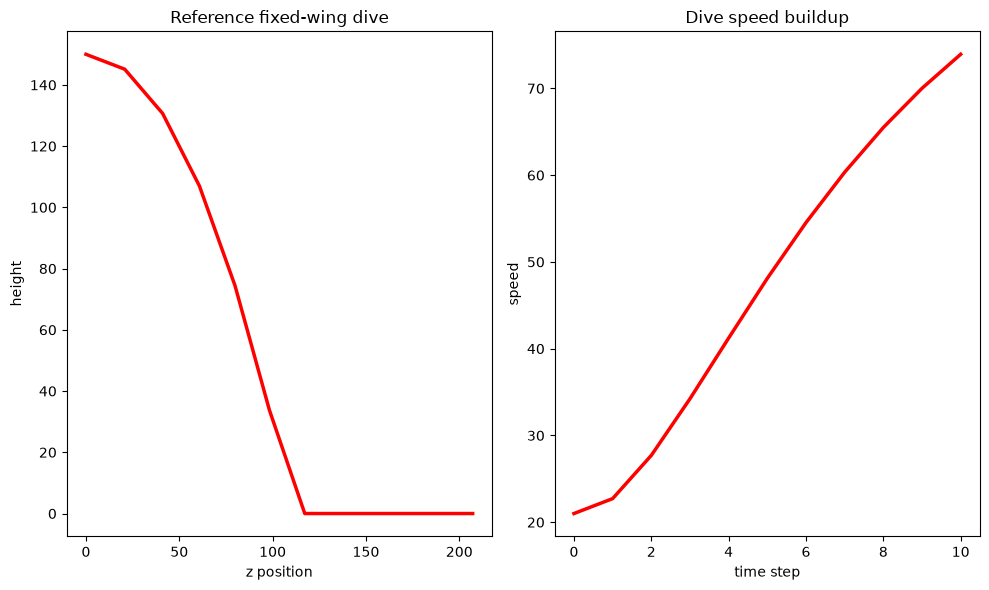

In [13]:
# Reference fixed-wing parameters are stored separately from the provisional and BYU models.
config['vehicle_models']['reference_fixed_wing_dive'] = {
    'mass': 1.5, 'gravity': 9.81, 'air_density': 1.225, 'wing_area': 0.1,
    'cd_constant': 0.025, 'v_stall': 14.0, 'v_max': 100.0,
    'powered_speed': 21.0, 'control_time_constant': 1.0,
    'gamma_command_min_deg': -90.0, 'gamma_command_max_deg': 0.0,
    'source': 'p1b_main.ipynb reference fixed-wing RK4 dynamics',
}
reference_vehicle = config['vehicle_models']['reference_fixed_wing_dive']
reference_vehicle['cl_max'] = (reference_vehicle['mass'] * reference_vehicle['gravity']
                               / (0.5 * reference_vehicle['air_density']
                                  * reference_vehicle['v_stall']**2
                                  * reference_vehicle['wing_area']))
config['fixed_wing_primitive_test'] = {
    'integration_step': 1.0, 'dive_command_deg': -70.0,
    'validation_duration': 10.0, 'initial_state': (0.0, 150.0, 21.0, 0.0),
}


def create_reference_fixed_wing_dynamics(vehicle):
    """Create the reference Cartesian fixed-wing dynamics as a CasADi function.

    Parameters
    ----------
    vehicle : dict
        Reference mass, atmosphere, wing, drag, and controller parameters.

    Returns
    casadi.Function
        Maps ``[z, h, vz, vh, gamma_cmd]`` to Cartesian state derivatives.
    """
    z_symbol, h_symbol, vz_symbol, vh_symbol, command_symbol = ca.SX.sym('z'), ca.SX.sym('h'), ca.SX.sym('vz'), ca.SX.sym('vh'), ca.SX.sym('gamma_cmd')
    speed = ca.sqrt(vz_symbol**2 + vh_symbol**2)
    safe_speed = ca.fmax(speed, 1.0e-6)
    gamma = ca.atan2(vh_symbol, vz_symbol)
    lift_required = (vehicle['mass'] * safe_speed * (command_symbol - gamma) / vehicle['control_time_constant']
                     + vehicle['mass'] * vehicle['gravity'] * ca.cos(gamma))
    cl = ca.fmin(ca.fmax(lift_required / (0.5 * vehicle['air_density'] * safe_speed**2 * vehicle['wing_area']), 0.0), vehicle['cl_max'])
    lift = 0.5 * vehicle['air_density'] * speed**2 * cl * vehicle['wing_area']
    drag = 0.5 * vehicle['air_density'] * speed**2 * vehicle['cd_constant'] * vehicle['wing_area']
    derivatives = ca.vertcat(vz_symbol, vh_symbol, (-drag * vz_symbol - lift * vh_symbol) / (safe_speed * vehicle['mass']), (-drag * vh_symbol + lift * vz_symbol) / (safe_speed * vehicle['mass']) - vehicle['gravity'])
    return ca.Function('ReferenceFixedWingDynamics', [z_symbol, h_symbol, vz_symbol, vh_symbol, command_symbol], [derivatives])


def integrate_reference_fixed_wing(state, gamma_command, dynamics_function, time_step):
    """Advance ``[z, h, v, gamma]`` with the reference RK4 fixed-wing model.

    Parameters
    ----------
    state : numpy.ndarray
        Physical state with gamma in radians.
    gamma_command : float
        Commanded flight-path angle in radians.
    dynamics_function : casadi.Function
        Cartesian symbolic derivative function.
    time_step : float
        RK4 integration interval in seconds.

    Returns
    numpy.ndarray
        Next physical state ``[z, h, v, gamma]``.
    """
    z_value, h_value, speed, gamma = np.asarray(state, dtype=float)
    cartesian_state = np.array([z_value, h_value, speed * np.cos(gamma), speed * np.sin(gamma)])
    derivative = lambda value: np.asarray(dynamics_function(*value, gamma_command), dtype=float).reshape(4)
    k1 = derivative(cartesian_state); k2 = derivative(cartesian_state + 0.5 * time_step * k1)
    k3 = derivative(cartesian_state + 0.5 * time_step * k2); k4 = derivative(cartesian_state + time_step * k3)
    next_cartesian = cartesian_state + time_step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0
    z_next, h_next, vz_next, vh_next = next_cartesian
    return np.array([z_next, max(h_next, 0.0), np.hypot(vz_next, vh_next), np.arctan2(vh_next, vz_next)])


reference_dynamics = create_reference_fixed_wing_dynamics(reference_vehicle)
reference_state = np.asarray(config['fixed_wing_primitive_test']['initial_state'], dtype=float)
reference_command = np.deg2rad(config['fixed_wing_primitive_test']['dive_command_deg'])
reference_history = [reference_state.copy()]
for _ in range(int(config['fixed_wing_primitive_test']['validation_duration'] / config['fixed_wing_primitive_test']['integration_step'])):
    reference_state = integrate_reference_fixed_wing(reference_state, reference_command, reference_dynamics, config['fixed_wing_primitive_test']['integration_step'])
    reference_history.append(reference_state.copy())
reference_history = np.asarray(reference_history)
assert reference_vehicle['cl_max'] > 0.0
assert reference_history[-1, 2] > reference_history[0, 2], 'Reference dive should build speed.'
figure, axes = plt.subplots(1, 2, figsize=config['visualization']['figure_size'])
axes[0].plot(reference_history[:, 0], reference_history[:, 1], color='red', linewidth=2.5); axes[0].set(xlabel='z position', ylabel='height', title='Reference fixed-wing dive')
axes[1].plot(np.arange(reference_history.shape[0]), reference_history[:, 2], color='red', linewidth=2.5); axes[1].set(xlabel='time step', ylabel='speed', title='Dive speed buildup')
figure.tight_layout()


## 14. Fixed-Wing Maneuver Primitive Library

Each edge candidate is a dense rollout of the validated reference RK4 fixed-wing dynamics. Non-terminal primitives must return close to the canonical speed and flight-path angle; terminal dives are exempt because no successor edge follows them.

Accepted primitives: 16 / 58
trim_glide dz= 83.9 dh= -3.9 v_exit= 21.0 gamma_exit= -2.6
dive_20_recover_1_12 dz= 298.9 dh= -20.5 v_exit= 22.8 gamma_exit= -2.6
dive_20_recover_1_20 dz= 478.8 dh= -28.8 v_exit= 22.3 gamma_exit= -2.6
dive_20_recover_1_30 dz= 698.7 dh= -38.9 v_exit= 21.8 gamma_exit= -2.6
dive_20_recover_1_40 dz= 914.9 dh= -48.8 v_exit= 21.5 gamma_exit= -2.6
dive_20_recover_2_30 dz= 765.2 dh= -49.5 v_exit= 22.5 gamma_exit= -2.6
dive_20_recover_2_40 dz= 987.0 dh= -59.7 v_exit= 22.0 gamma_exit= -2.6
dive_20_recover_3_40 dz= 1056.5 dh= -71.2 v_exit= 22.3 gamma_exit= -2.6
dive_45_recover_1_30 dz= 747.4 dh= -49.6 v_exit= 22.6 gamma_exit= -2.6
dive_45_recover_1_40 dz= 970.1 dh= -59.8 v_exit= 22.0 gamma_exit= -2.6
dive_45_recover_2_40 dz= 1096.9 dh= -86.8 v_exit= 22.9 gamma_exit= -2.6
dive_70_recover_1_30 dz= 749.0 dh= -50.0 v_exit= 22.6 gamma_exit= -2.6
dive_70_recover_1_40 dz= 971.9 dh= -60.2 v_exit= 22.0 gamma_exit= -2.6
terminal_dive_45 dz= 153.5 dh= -126.2 v_exit= 48.6 gamma_e

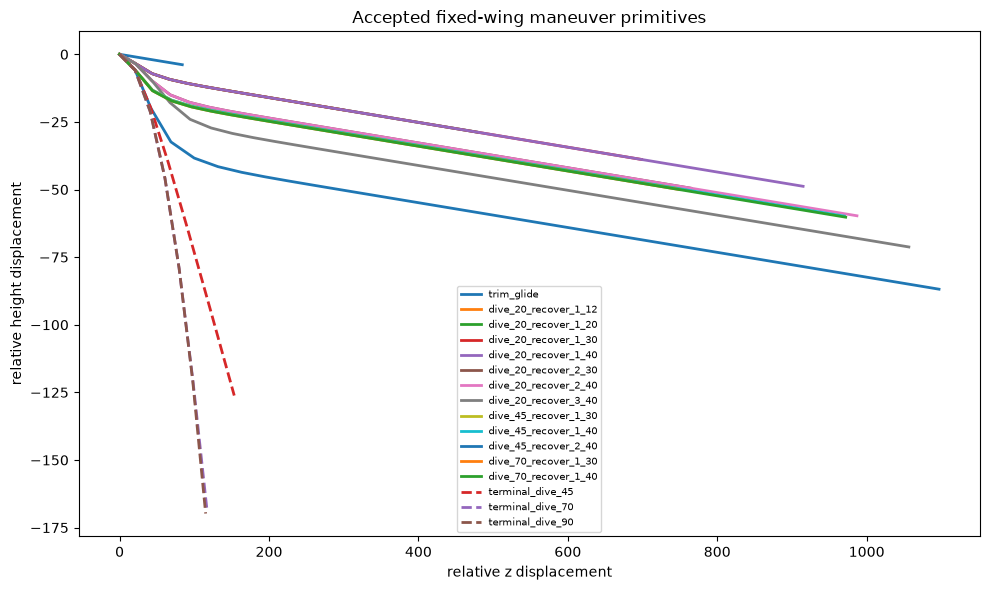

In [15]:
canonical_speed = 21.0
canonical_cl = (reference_vehicle['mass'] * reference_vehicle['gravity'] / (0.5 * reference_vehicle['air_density'] * canonical_speed**2 * reference_vehicle['wing_area']))
canonical_gamma_deg = float(np.rad2deg(-np.arctan(reference_vehicle['cd_constant'] / canonical_cl)))
config['fixed_wing_primitive_test'].update({'canonical_speed': canonical_speed, 'canonical_gamma_deg': canonical_gamma_deg, 'speed_recovery_tolerance': 2.0, 'gamma_recovery_tolerance_deg': 3.0, 'library_reference_height': 1000.0, 'recovery_command_deg': canonical_gamma_deg})

def rollout_fixed_wing_schedule(initial_state, command_schedule, dynamics_function, time_step):
    """Roll out a piecewise-constant gamma-command schedule with RK4 dynamics.

    Parameters
    ----------
    initial_state : array_like
        Initial physical state ``[z, h, v, gamma]`` with gamma in radians.
    command_schedule : list of tuple
        Pairs of ``(gamma_command_deg, duration_seconds)``.

    Returns
    -------
    tuple of numpy.ndarray
        Dense state history and applied command history.
    """
    state=np.asarray(initial_state,dtype=float).copy(); states=[state.copy()]; commands=[]
    for command_deg,duration in command_schedule:
        for _ in range(int(round(duration/time_step))):
            state=integrate_reference_fixed_wing(state,np.deg2rad(command_deg),dynamics_function,time_step); states.append(state.copy()); commands.append(command_deg)
            if state[1]<=0.0: return np.asarray(states),np.asarray(commands)
    return np.asarray(states),np.asarray(commands)

def build_fixed_wing_primitive(name, schedule, terminal):
    """Create one translated fixed-wing maneuver primitive and test its exit envelope."""
    settings=config['fixed_wing_primitive_test']; initial=np.array([0.0,settings['library_reference_height'],settings['canonical_speed'],np.deg2rad(settings['canonical_gamma_deg'])])
    states,commands=rollout_fixed_wing_schedule(initial,schedule,reference_dynamics,settings['integration_step'])
    speed_error=abs(states[-1,2]-settings['canonical_speed']); gamma_error=abs(np.rad2deg(states[-1,3])-settings['canonical_gamma_deg'])
    accepted=terminal or (states[-1,1]>0.0 and speed_error<=settings['speed_recovery_tolerance'] and gamma_error<=settings['gamma_recovery_tolerance_deg'])
    return {'name':name,'terminal':terminal,'states':states,'commands':commands,'delta_z':float(states[-1,0]),'delta_h':float(states[-1,1]-initial[1]),'elapsed_time':float(len(commands)*settings['integration_step']),'exit_speed':float(states[-1,2]),'exit_gamma_deg':float(np.rad2deg(states[-1,3])),'accepted':bool(accepted)}

primitive_specs=[('trim_glide',[(canonical_gamma_deg,4.0)],False)]
for dive_command in (-20.0,-45.0,-70.0):
    for dive_duration in (1.0,2.0,3.0):
        for recovery_duration in (4.0,8.0,12.0,20.0,30.0,40.0): primitive_specs.append((f'dive_{abs(dive_command):.0f}_recover_{dive_duration:.0f}_{recovery_duration:.0f}',[(dive_command,dive_duration),(canonical_gamma_deg,recovery_duration)],False))
primitive_specs.extend([('terminal_dive_45',[(-45.0,6.0)],True),('terminal_dive_70',[(-70.0,6.0)],True),('terminal_dive_90',[(-90.0,6.0)],True)])
all_fixed_wing_primitives=[build_fixed_wing_primitive(name,schedule,terminal) for name,schedule,terminal in primitive_specs]
fixed_wing_primitives=[primitive for primitive in all_fixed_wing_primitives if primitive['accepted']]
assert any(primitive['terminal'] for primitive in fixed_wing_primitives)
print('Accepted primitives:',len(fixed_wing_primitives),'/',len(all_fixed_wing_primitives))
for primitive in fixed_wing_primitives: print(primitive['name'],'dz=',round(primitive['delta_z'],1),'dh=',round(primitive['delta_h'],1),'v_exit=',round(primitive['exit_speed'],1),'gamma_exit=',round(primitive['exit_gamma_deg'],1))
figure,axis=plt.subplots(figsize=config['visualization']['figure_size'])
for primitive in fixed_wing_primitives: axis.plot(primitive['states'][:,0],primitive['states'][:,1]-config['fixed_wing_primitive_test']['library_reference_height'],'--' if primitive['terminal'] else '-',linewidth=2,label=primitive['name'])
axis.set(xlabel='relative z displacement',ylabel='relative height displacement',title='Accepted fixed-wing maneuver primitives'); axis.legend(fontsize=7); figure.tight_layout()


## 15. Terrain-, LOS-, and Sensor-Aware 2D Primitive Edges

The DP state remains `(z, h)`. At each cell, every accepted primitive is translated to that cell, checked at every stored RK4 substep, and assigned an integrated sensor/time cost. The resulting directed edge retains its dense fixed-wing state history for later path reconstruction.

Valid primitive edges: 13398


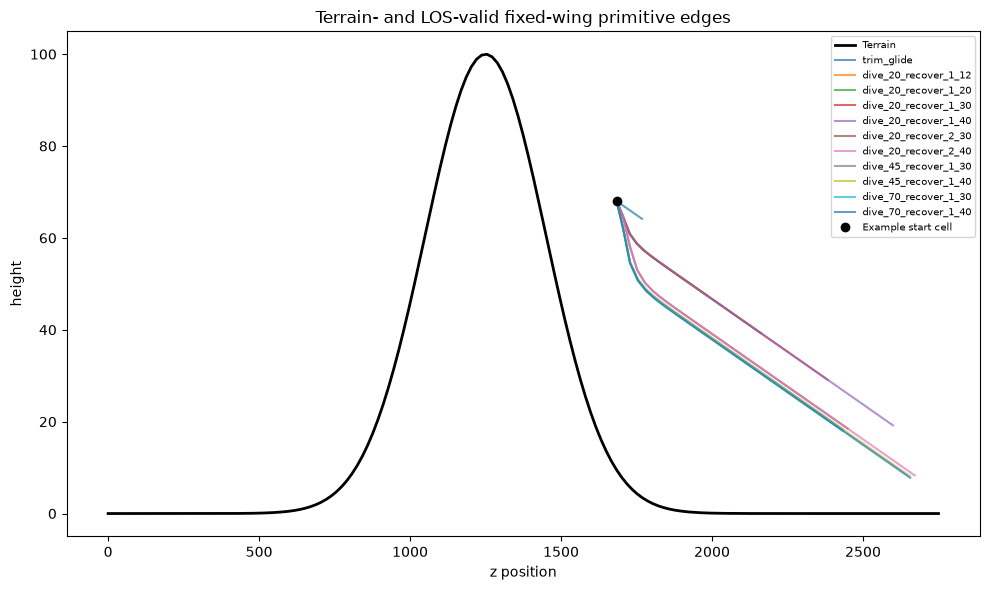

In [16]:
config['fixed_wing_primitive_test'].update({'edge_z_count': 81, 'edge_h_count': 51, 'edge_start_z': 1700.0, 'edge_start_h': 70.0})

def translated_primitive_states(primitive, z_start, h_start):
    """Translate a relative primitive trajectory to a physical 2D start cell.

    Parameters
    ----------
    primitive : dict
        Dense fixed-wing primitive returned by ``build_fixed_wing_primitive``.
    z_start, h_start : float
        Physical start coordinates of the 2D DP edge.

    Returns
    numpy.ndarray
        Dense physical ``[z, h, v, gamma]`` state trajectory.
    """
    states = primitive['states'].copy()
    states[:, 0] += z_start - states[0, 0]
    states[:, 1] += h_start - states[0, 1]
    return states

def nearest_2d_index(z_value, h_value, z_values, h_values):
    """Return the nearest in-domain 2D grid index, or None outside the grid."""
    if z_value < z_values[0] or z_value > z_values[-1] or h_value < h_values[0] or h_value > h_values[-1]:
        return None
    return int(np.argmin(np.abs(z_values - z_value))), int(np.argmin(np.abs(h_values - h_value)))

def evaluate_primitive_edge(z_start, h_start, primitive, z_values, h_values):
    """Validate and cost one translated fixed-wing primitive edge.

    Every non-terminal sample must satisfy terrain clearance and LOS. A terminal
    primitive may touch the ground only at a goal-region final sample.
    """
    states = translated_primitive_states(primitive, z_start, h_start)
    endpoint = states[-1]; endpoint_is_goal = is_goal_region(endpoint[0], endpoint[1], config)
    if primitive['terminal'] and not endpoint_is_goal:
        return None
    if not primitive['terminal'] and not endpoint_is_goal:
        endpoint_index = nearest_2d_index(endpoint[0], endpoint[1], z_values, h_values)
        if endpoint_index is None:
            return None
    else:
        endpoint_index = nearest_2d_index(config['mission']['z_goal'], config['mission']['h_goal'], z_values, h_values)
    samples = states[:-1] if endpoint_is_goal else states
    edge_cost = 0.0
    for state in samples:
        z_value, h_value, speed, gamma_value = state
        if h_value < terrain(z_value) + config['solver']['terrain_clearance'] or not in_los(z_value, h_value):
            return None
        edge_cost += float(J4DFunction(z_value, h_value, speed, gamma_value)) * config['fixed_wing_primitive_test']['integration_step'] / config['solver']['dt_reference']
    if not np.isfinite(edge_cost) or edge_cost < 0.0:
        return None
    return {'next_index': endpoint_index, 'primitive_name': primitive['name'], 'primitive': primitive, 'cost': float(edge_cost), 'states': states}

def build_fixed_wing_primitive_edges(z_values, h_values, primitives):
    """Create all valid 2D outgoing edges from dense fixed-wing primitives."""
    edges = [[[] for _ in h_values] for _ in z_values]
    for iz, z_value in enumerate(z_values):
        for ih, h_value in enumerate(h_values):
            if h_value < terrain(z_value) + config['solver']['terrain_clearance'] or not in_los(z_value, h_value):
                continue
            for primitive in primitives:
                edge = evaluate_primitive_edge(z_value, h_value, primitive, z_values, h_values)
                if edge is not None:
                    edges[iz][ih].append(edge)
    return edges

primitive_z_grid = np.linspace(config['grid']['z_min'], config['grid']['z_max'], config['fixed_wing_primitive_test']['edge_z_count'])
primitive_h_grid = np.linspace(config['grid']['h_min'], config['grid']['h_max'], config['fixed_wing_primitive_test']['edge_h_count'])
primitive_edges = build_fixed_wing_primitive_edges(primitive_z_grid, primitive_h_grid, fixed_wing_primitives)
primitive_edge_count = sum(len(edges) for row in primitive_edges for edges in row)
assert primitive_edge_count > 0, 'No terrain- and LOS-valid fixed-wing primitive edges were created.'
print('Valid primitive edges:', primitive_edge_count)
start_index = nearest_2d_index(config['fixed_wing_primitive_test']['edge_start_z'], config['fixed_wing_primitive_test']['edge_start_h'], primitive_z_grid, primitive_h_grid)
figure, axis = plt.subplots(figsize=config['visualization']['figure_size'])
axis.plot(terrain_z, terrain_h, 'k-', linewidth=2, label='Terrain')
if start_index is not None:
    start_z, start_h = primitive_z_grid[start_index[0]], primitive_h_grid[start_index[1]]
    for edge in primitive_edges[start_index[0]][start_index[1]]:
        axis.plot(edge['states'][:, 0], edge['states'][:, 1], alpha=.7, label=edge['primitive_name'])
    axis.plot(start_z, start_h, 'ko', label='Example start cell')
axis.set(xlabel='z position', ylabel='height', title='Terrain- and LOS-valid fixed-wing primitive edges'); axis.legend(fontsize=7); figure.tight_layout()


## 16. 2D Primitive Cost-to-Go and Dense Fixed-Wing Path

Reverse Dijkstra operates only on `(z, h)` nodes, but every edge is the dense fixed-wing trajectory stored in Section 15. Parent selection stores both the successor cell and primitive identity so the final path can be reconstructed with its physical speed and flight-path-angle history.

Finite primitive cost-to-go states: 228 / 4131
Example primitive path edges: []


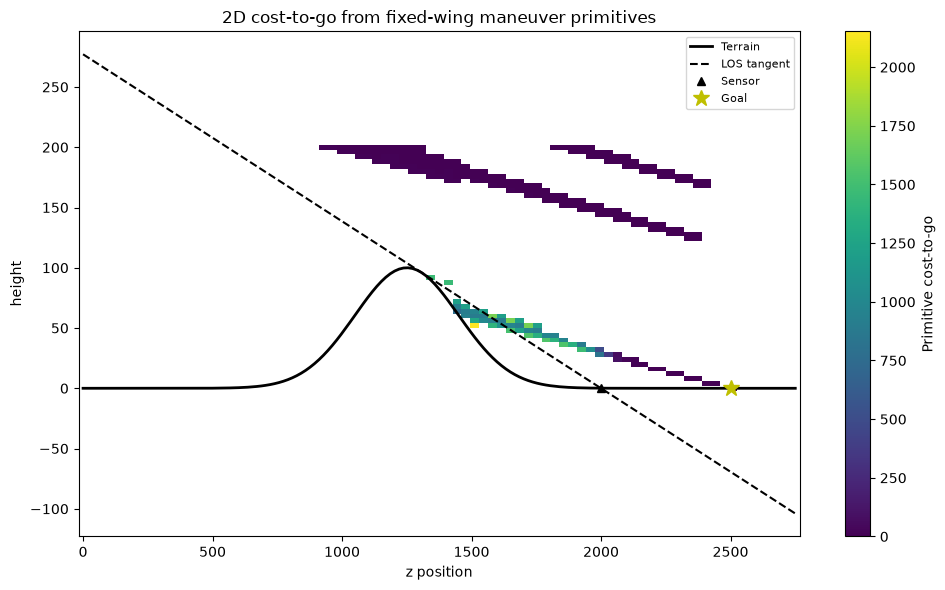

In [19]:
def solve_primitive_cost_to_go(z_values, h_values, edge_graph):
    """Compute 2D cost-to-go over fixed-wing maneuver-primitive edges.

    Parameters
    ----------
    z_values, h_values : numpy.ndarray
        2D planner coordinate grids.
    edge_graph : list
        Outgoing edge lists created by ``build_fixed_wing_primitive_edges``.

    Returns
    dict
        Cost-to-go, parent indices, parent primitive IDs, and parent edge objects.
    """
    shape=(z_values.size,h_values.size); state_count=int(np.prod(shape)); reverse_edges=[[] for _ in range(state_count)]
    primitive_names=sorted({edge['primitive_name'] for row in edge_graph for edges in row for edge in edges}); primitive_id={name:index for index,name in enumerate(primitive_names)}
    for iz,row in enumerate(edge_graph):
        for ih,edges in enumerate(row):
            source_flat=np.ravel_multi_index((iz,ih),shape)
            for edge in edges:
                destination_flat=np.ravel_multi_index(edge['next_index'],shape)
                reverse_edges[destination_flat].append((source_flat,edge['cost'],primitive_id[edge['primitive_name']],edge))
    goal_index=nearest_2d_index(config['mission']['z_goal'],config['mission']['h_goal'],z_values,h_values)
    if goal_index is None: raise RuntimeError('Goal is outside the primitive-DP grid.')
    goal_flat=np.ravel_multi_index(goal_index,shape); cost_flat=np.full(state_count,np.inf); parent_flat=np.full(state_count,-1,dtype=int); parent_primitive=np.full(state_count,-1,dtype=int); parent_edge=np.empty(state_count,dtype=object); parent_edge[:]=None
    cost_flat[goal_flat]=0.0; frontier=[(0.0,int(goal_flat))]
    while frontier:
        successor_cost,successor_flat=heapq.heappop(frontier)
        if successor_cost!=cost_flat[successor_flat]: continue
        for predecessor_flat,edge_cost,primitive_index,edge in reverse_edges[successor_flat]:
            candidate_cost=successor_cost+edge_cost
            if candidate_cost<cost_flat[predecessor_flat]:
                cost_flat[predecessor_flat]=candidate_cost; parent_flat[predecessor_flat]=successor_flat; parent_primitive[predecessor_flat]=primitive_index; parent_edge[predecessor_flat]=edge; heapq.heappush(frontier,(candidate_cost,predecessor_flat))
    return {'CostToGoPrimitive2D':cost_flat.reshape(shape),'ParentFlatIndex':parent_flat.reshape(shape),'ParentPrimitiveId':parent_primitive.reshape(shape),'ParentEdge':parent_edge.reshape(shape),'primitive_names':primitive_names,'goal_index':goal_index}

def extract_dense_primitive_path(solution, start_index):
    """Follow 2D parents while concatenating their dense fixed-wing trajectories."""
    cost=solution['CostToGoPrimitive2D']; shape=cost.shape
    if start_index is None or not np.isfinite(cost[start_index]): return np.empty((0,4)),[]
    current_flat=np.ravel_multi_index(start_index,shape); goal_flat=np.ravel_multi_index(solution['goal_index'],shape); states=[]; names=[]; visited=set()
    while current_flat!=goal_flat and current_flat not in visited:
        visited.add(current_flat); current_index=np.unravel_index(current_flat,shape); edge=solution['ParentEdge'][current_index]
        if edge is None: return np.empty((0,4)),[]
        dense_states=edge['states']; states.extend(dense_states if not states else dense_states[1:]); names.append(edge['primitive_name']); current_flat=solution['ParentFlatIndex'][current_index]
    return np.asarray(states),names

primitive_dp_solution=solve_primitive_cost_to_go(primitive_z_grid,primitive_h_grid,primitive_edges)
PrimitiveCostToGo=primitive_dp_solution['CostToGoPrimitive2D']
assert PrimitiveCostToGo.shape==(primitive_z_grid.size,primitive_h_grid.size)
assert PrimitiveCostToGo[primitive_dp_solution['goal_index']]==0.0
finite_primitive_states=np.count_nonzero(np.isfinite(PrimitiveCostToGo)); print('Finite primitive cost-to-go states:',finite_primitive_states,'/',PrimitiveCostToGo.size)
primitive_start_index=nearest_2d_index(config['fixed_wing_primitive_test']['edge_start_z'],config['fixed_wing_primitive_test']['edge_start_h'],primitive_z_grid,primitive_h_grid)
primitive_path,primitive_path_names=extract_dense_primitive_path(primitive_dp_solution,primitive_start_index)
print('Example primitive path edges:',primitive_path_names)

figure,axis=plt.subplots(figsize=config['visualization']['figure_size'])
image=axis.pcolormesh(primitive_z_grid,primitive_h_grid,np.ma.masked_invalid(PrimitiveCostToGo).T,shading='auto',cmap=config['visualization']['cost_colormap'])
axis.plot(terrain_z,terrain_h,'k-',linewidth=2,label='Terrain'); axis.plot(z_grid,tangent_slope*z_grid+tangent_intercept,'k--',label='LOS tangent'); axis.plot(config['mission']['z_sensor'],config['mission']['h_sensor'],'k^',label='Sensor'); axis.plot(config['mission']['z_goal'],config['mission']['h_goal'],'y*',markersize=12,label='Goal')
if primitive_path.size: axis.plot(primitive_path[:,0],primitive_path[:,1],'r-',linewidth=3,label='Dense fixed-wing primitive path')
axis.set(xlabel='z position',ylabel='height',title='2D cost-to-go from fixed-wing maneuver primitives'); axis.legend(fontsize=8); figure.colorbar(image,ax=axis,label='Primitive cost-to-go'); figure.tight_layout()
